# **Applied Machine Learning - Basic courses Final Project**

## **Student Name**: *Negin Nillforoosh* - **Matricola:** *1164045*

# Heart Disease Prediction with Machine Learning

In this notebook, I explore a heart disease dataset and train several machine learning classifiers to predict whether a patient has heart disease. The notebook is organized in a simple workflow: data loading, exploratory data analysis, preprocessing, model training, and result comparison.

The goal is not only to get a high accuracy score, but also to understand the dataset, explain the preprocessing choices, and compare the behavior of different models in a clear way.


## 1. Setup and imports

This first cell prepares the notebook. I import pandas and NumPy for data handling, Matplotlib and Seaborn for visualization, and several scikit-learn tools for preprocessing, training, and evaluating machine learning models. I also set a random state to make the results more reproducible.


In [1]:
# I keep the main libraries and model imports together so the notebook can be run from top to bottom easily.
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 2. Loading the dataset

Here I download the heart disease dataset directly from Kaggle. This makes the notebook easier to reproduce because the dataset is loaded from a fixed source instead of depending on a local file path.


In [2]:
# I use kagglehub here to download the dataset directly instead of manually uploading the CSV file.
import kagglehub

# Download latest version
path = kagglehub.dataset_download("johnsmith88/heart-disease-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-disease-dataset' dataset.
Path to dataset files: /kaggle/input/heart-disease-dataset


After downloading the dataset, I read the CSV file into a DataFrame named `df`. Displaying the first few rows gives a quick check that the file was loaded correctly and that the columns look as expected.


In [3]:
# After downloading the dataset, I read the CSV file into a pandas DataFrame for analysis.
DATA_PATH = path + "/heart.csv"   # change this path if needed

df = pd.read_csv(DATA_PATH)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


**Result interpretation:** The first rows confirm that the dataset contains common heart disease prediction variables such as age, sex, chest pain type, blood pressure, cholesterol, maximum heart rate, and the binary target label.


## 3. First look at the data

The shape of the dataset tells us the number of samples and columns. In this notebook, the dataset has **1025 rows** and **14 columns**, which is enough for a basic classification experiment but still small enough that overfitting should be considered.


In [4]:
# This quick shape check tells me how many rows and features are available before modeling.
print("Shape:", df.shape)

Shape: (1025, 14)


The `info()` output is useful because it shows column names, data types, and missing values. Here, all columns have 1025 non-null values, so there is no immediate missing-value problem to solve.


In [5]:
# I check column types and missing values before deciding how to preprocess the data.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


**Result interpretation:** Since there are no missing values in the displayed `info()` output, this notebook does not need imputation. The main preprocessing need is handling categorical variables and scaling numerical ranges.


Some columns are stored as integers, but they are actually categorical labels. For example, chest pain type (`cp`) and thalassemia (`thal`) are category codes, not continuous numeric measurements. I convert them to `object` so the analysis treats them more like categories.


In [6]:
# These columns are categorical codes, so I convert them to object type before visualization/encoding.
lst=['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
df[lst] = df[lst].astype(object)

An ID column, if present, would only identify rows and would not provide useful medical information. Removing it prevents the model from learning meaningless row identifiers.


In [7]:
# Some datasets include an id column; it is not predictive, so I remove it if it exists.
if "id" in df.columns:
    df = df.drop(columns=["id"])

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 4. Exploratory Data Analysis: categorical features

This plot checks the distribution of `sex`. The output shows **713 male** and **312 female** records, so the dataset is not gender-balanced. This matters because the model may learn patterns that are more representative of the majority group.


Sex (Gender) Total :


,count
sex,
1,713
0,312


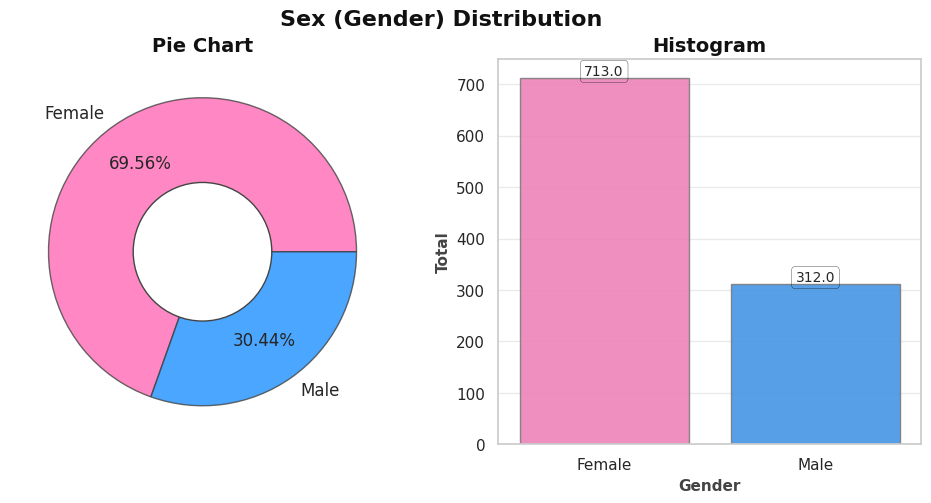

In [8]:
# I visualize the gender distribution to understand whether the dataset is balanced across sex groups.
colors=['#FF69B4', '#1E90FF']
labels=['Female', 'Male']
order=df['sex'].value_counts().index

# Size for Both Figures
plt.figure(figsize=(12, 5))
plt.suptitle('Sex (Gender) Distribution', fontweight='heavy',
             fontsize='16', fontfamily='sans-serif', color='#111111')

# Pie Chart
plt.subplot(1, 2, 1)
plt.title('Pie Chart', fontweight='bold', fontsize=14,
          fontfamily='sans-serif', color='#111111')
plt.pie(df['sex'].value_counts(), labels=labels, colors=colors, pctdistance=0.7,
        autopct='%.2f%%', wedgeprops=dict(alpha=0.8, edgecolor='#444444'),
        textprops={'fontsize':12})
centre=plt.Circle((0, 0), 0.45, fc='white', edgecolor='#444444')
plt.gcf().gca().add_artist(centre)

# Histogram
countplt = plt.subplot(1, 2, 2)
plt.title('Histogram', fontweight='bold', fontsize=14,
          fontfamily='sans-serif', color='#111111')
ax = sns.countplot(x='sex', data=df, palette=colors, order=order,
                   edgecolor='#777777', alpha=0.85)
for rect in ax.patches:
    ax.text (rect.get_x()+rect.get_width()/2,
             rect.get_height()+4.25,rect.get_height(),
             horizontalalignment='center', fontsize=10,
             bbox=dict(facecolor='none', edgecolor='#111111',
                       linewidth=0.25, boxstyle='round'))

plt.xlabel('Gender', fontweight='bold', fontsize=11, fontfamily='sans-serif',
           color='#444444')
plt.ylabel('Total', fontweight='bold', fontsize=11, fontfamily='sans-serif',
           color='#444444')
plt.xticks([0, 1], labels)
plt.grid(axis='y', alpha=0.4)
countplt

# Count Categorical Labels without dropping null values
print('\033[1m'+'Sex (Gender) Total :'+'\033[0m')
df.sex.value_counts(dropna=False)

**Chart analysis:** The dataset contains more male than female patients. This imbalance should be kept in mind when interpreting gender-based patterns, because the model has more male examples to learn from.


This cell visualizes chest pain type (`cp`). Chest pain type 0 is the most common group, followed by type 2 and type 1, while type 3 is the least common. Since chest pain is medically relevant, this feature may help the classifier separate patients with and without heart disease.


 Chest Pain Type Total :


,count
cp,
0,497
2,284
1,167
3,77


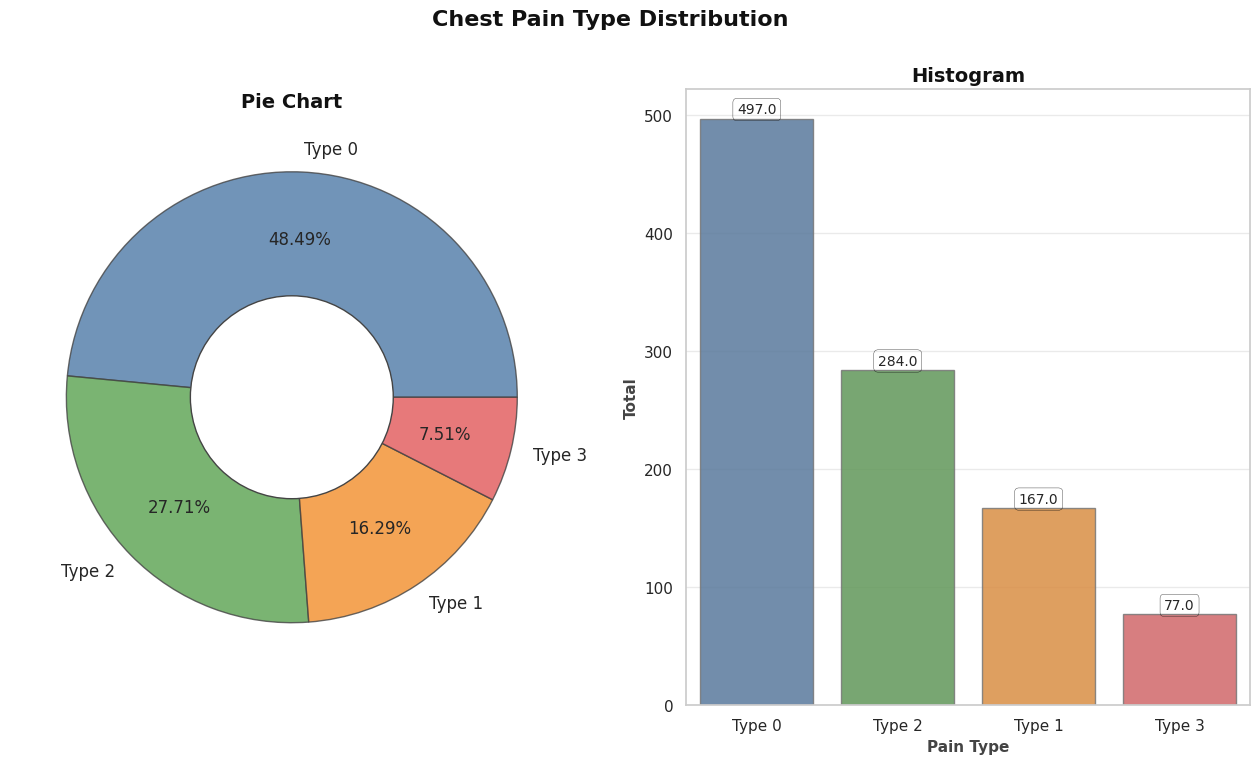

In [9]:
# I check chest pain types because this feature is clinically meaningful and may be related to the target.
colors=['#4E79A7', '#59A14F', '#F28E2B', '#E15759']
labels=['Type 0', 'Type 2', 'Type 1', 'Type 3']
order=df['cp'].value_counts().index

# Size for Both Figures
plt.figure(figsize=(16, 8))
plt.suptitle('Chest Pain Type Distribution', fontweight='heavy', fontsize=16,
             fontfamily='sans-serif', color='#111111')

# Pie Chart
plt.subplot(1, 2, 1)
plt.title('Pie Chart', fontweight='bold', fontsize=14,fontfamily='sans-serif',
          color='#111111')
plt.pie(df['cp'].value_counts(), labels=labels, colors=colors, pctdistance=0.7,
        autopct='%.2f%%', textprops={'fontsize':12},
        wedgeprops=dict(alpha=0.8, edgecolor='#444444'))
centre=plt.Circle((0, 0), 0.45, fc='white', edgecolor='#444444')
plt.gcf().gca().add_artist(centre)

# Histogram
countplt = plt.subplot(1, 2, 2)
plt.title('Histogram', fontweight='bold', fontsize=14, fontfamily='sans-serif',
          color='#111111')
ax = sns.countplot(x='cp', data=df, palette=colors, order=order,
                   edgecolor='#777777', alpha=0.85)
for rect in ax.patches:
    ax.text (rect.get_x()+rect.get_width()/2,
             rect.get_height()+4.25,rect.get_height(),
             horizontalalignment='center', fontsize=10,
             bbox=dict(facecolor='none', edgecolor='#111111', linewidth=0.25,
                       boxstyle='round'))

plt.xlabel('Pain Type', fontweight='bold', fontsize=11, fontfamily='sans-serif',
           color='#444444')
plt.ylabel('Total', fontweight='bold', fontsize=11, fontfamily='sans-serif',
           color='#444444')
plt.xticks([0, 1, 2, 3], labels)
plt.grid(axis='y', alpha=0.4)
countplt

# Count Categorical Labels without dropping null values
print('\033[1m'+' Chest Pain Type Total :'+'\033[0m')
df.cp.value_counts(dropna=False)

**Chart analysis:** Chest pain type 0 dominates the dataset. The less frequent categories, especially type 3, may still be important but have fewer examples for the model to learn from.


This plot checks fasting blood sugar (`fbs`). Most patients are in the `< 120 mg/dl` group (**872 records**) and far fewer are in the `> 120 mg/dl` group (**153 records**). This imbalance means `fbs` alone may not be a strong separator, but it can still contribute with other features.


Fasting Blood Sugar Total :


,count
fbs,
0,872
1,153


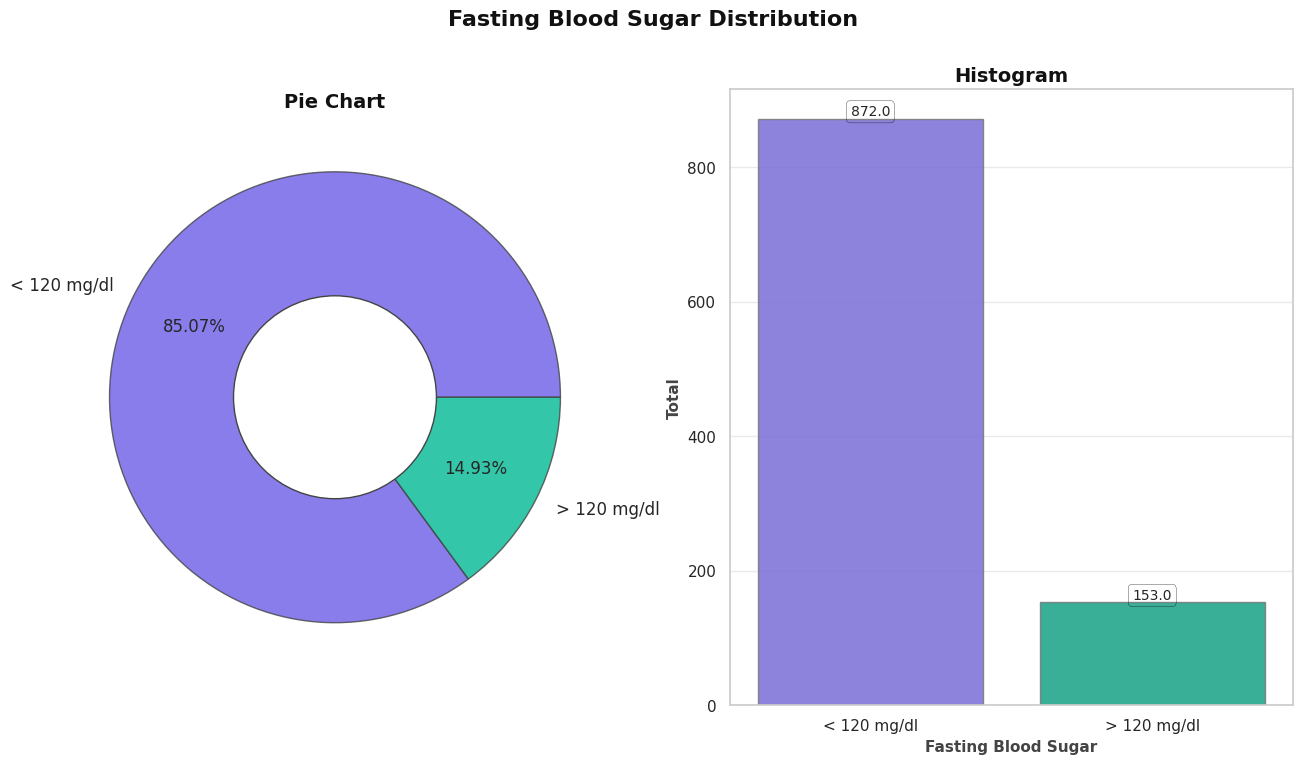

In [10]:
# I inspect fasting blood sugar to see whether this binary feature is balanced or dominated by one class.
colors=['#6C5CE7', '#00B894']
labels=['< 120 mg/dl', '> 120 mg/dl']
order=df['fbs'].value_counts().index

# Size for Both Figures
plt.figure(figsize=(16, 8))
plt.suptitle('Fasting Blood Sugar Distribution', fontweight='heavy',
             fontsize=16, fontfamily='sans-serif', color='#111111')

# Pie Chart
plt.subplot(1, 2, 1)
plt.title('Pie Chart', fontweight='bold', fontsize=14, fontfamily='sans-serif',
          color='#111111')
plt.pie(df['fbs'].value_counts(), labels=labels, colors=colors,
        wedgeprops=dict(alpha=0.8, edgecolor='#444444'), autopct='%.2f%%',
        pctdistance=0.7, textprops={'fontsize':12})
centre=plt.Circle((0, 0), 0.45, fc='white', edgecolor='#444444')
plt.gcf().gca().add_artist(centre)

# Histogram
countplt = plt.subplot(1, 2, 2)
plt.title('Histogram', fontweight='bold', fontsize=14, fontfamily='sans-serif',
          color='#111111')
ax = sns.countplot(x='fbs', data=df, palette=colors, order=order,
                   edgecolor='#777777', alpha=0.85)
for rect in ax.patches:
    ax.text (rect.get_x()+rect.get_width()/2,
             rect.get_height()+4.25,rect.get_height(),
             horizontalalignment='center', fontsize=10,
             bbox=dict(facecolor='none', edgecolor='#111111', linewidth=0.25,
                       boxstyle='round'))

plt.xlabel('Fasting Blood Sugar', fontweight='bold', fontsize=11,
           fontfamily='sans-serif', color='#444444')
plt.ylabel('Total', fontweight='bold', fontsize=11, fontfamily='sans-serif',
           color='#444444')
plt.xticks([0, 1], labels)
plt.grid(axis='y', alpha=0.4)
countplt


# Count Categorical Labels without dropping null values

print('\033[1m'+'Fasting Blood Sugar Total :'+'\033[0m')

df.fbs.value_counts(dropna=False)

**Chart analysis:** Fasting blood sugar is highly imbalanced. Most patients are below the threshold, so this feature may not be very powerful alone, but it can still add information when combined with other variables.


This cell visualizes resting electrocardiographic results (`restecg`). Categories 0 and 1 are both common, while category 2 appears very rarely. Rare categories can be harder for a model to learn reliably because there are fewer examples.


Resting Electrocardiographic Results Total :


,count
restecg,
1,513
0,497
2,15


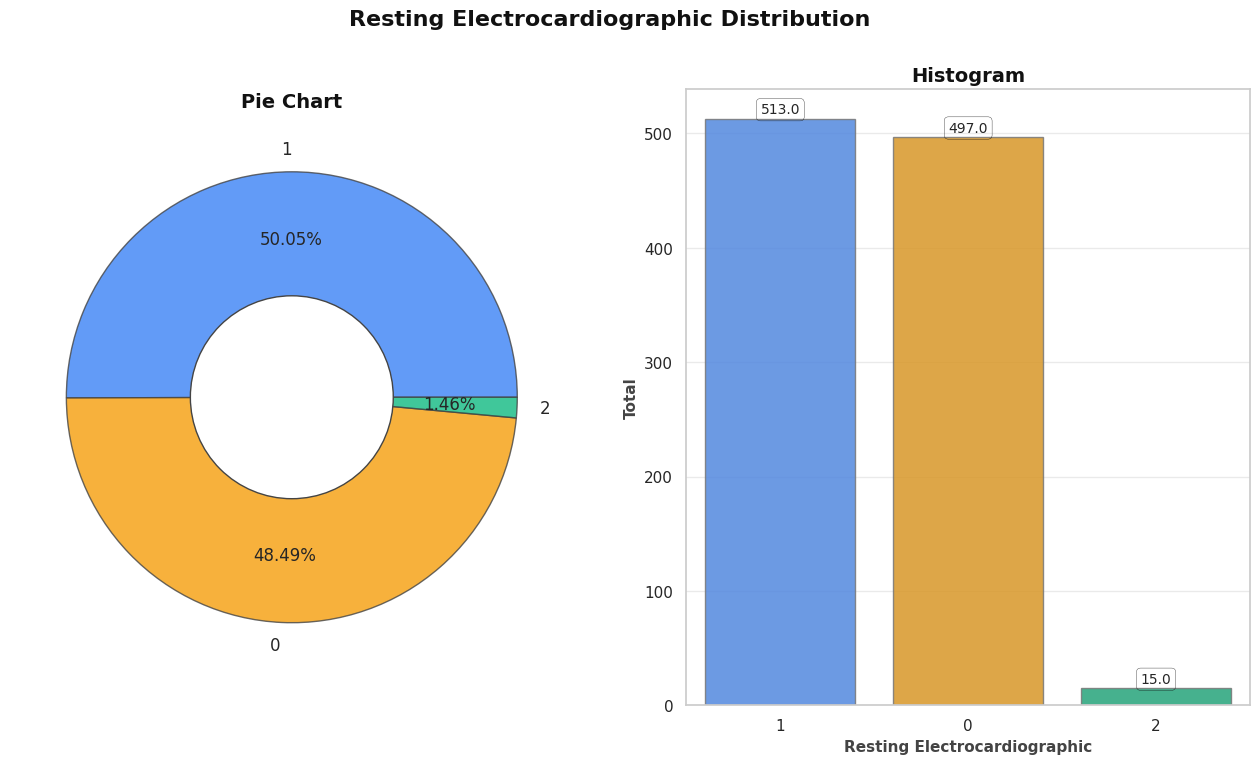

In [11]:
# I visualize resting ECG categories to understand how common each ECG result is in the dataset.

colors=['#3B82F6', '#F59E0B', '#10B981']
labels=['1', '0', '2']
order=df['restecg'].value_counts().index

# Size for Both Figures
plt.figure(figsize=(16, 8))
plt.suptitle('Resting Electrocardiographic Distribution', fontweight='heavy',
             fontsize=16, fontfamily='sans-serif', color='#111111')

# Pie Chart
plt.subplot(1,2,1)
plt.title('Pie Chart', fontweight='bold', fontsize=14, fontfamily='sans-serif',
          color='#111111')
plt.pie(df['restecg'].value_counts(), labels=labels, colors=colors,
        wedgeprops=dict(alpha=0.8, edgecolor='#444444'), autopct='%.2f%%',
        pctdistance=0.7, textprops={'fontsize':12})
centre=plt.Circle((0, 0), 0.45, fc='white', edgecolor='#444444')
plt.gcf().gca().add_artist(centre)

# Histogram
countplt = plt.subplot(1, 2, 2)
plt.title('Histogram', fontweight='bold', fontsize=14, fontfamily='sans-serif',
          color='#111111')
ax = sns.countplot(x='restecg', data=df, palette=colors, order=order,
                   edgecolor='#777777', alpha=0.85)
for rect in ax.patches:
    ax.text (rect.get_x()+rect.get_width()/2,
             rect.get_height()+4.25,rect.get_height(),
             horizontalalignment='center', fontsize=10,
             bbox=dict(facecolor='none', edgecolor='#111111', linewidth=0.25,
                       boxstyle='round'))

plt.xlabel('Resting Electrocardiographic', fontweight='bold', fontsize=11,
           fontfamily='sans-serif', color='#444444')
plt.ylabel('Total', fontweight='bold', fontsize=11, fontfamily='sans-serif',
           color='#444444')
plt.grid(axis='y', alpha=0.4)
countplt

# Count Categorical Labels without dropping null values
print('\033[1m'+'Resting Electrocardiographic Results Total :'+'\033[0m')

df.restecg.value_counts(dropna=False)

**Chart analysis:** `restecg` categories 0 and 1 are almost equally represented, while category 2 is rare. Rare categories may lead to less stable predictions unless there is enough supporting signal from other features.


This plot shows exercise-induced angina (`exang`). Most patients do not have exercise-induced angina (**680 records**), while **345 records** do. Because this feature relates to symptoms during exercise, it is likely useful for prediction.


.: Exercise Induced Angina Total :.


,count
exang,
0,680
1,345


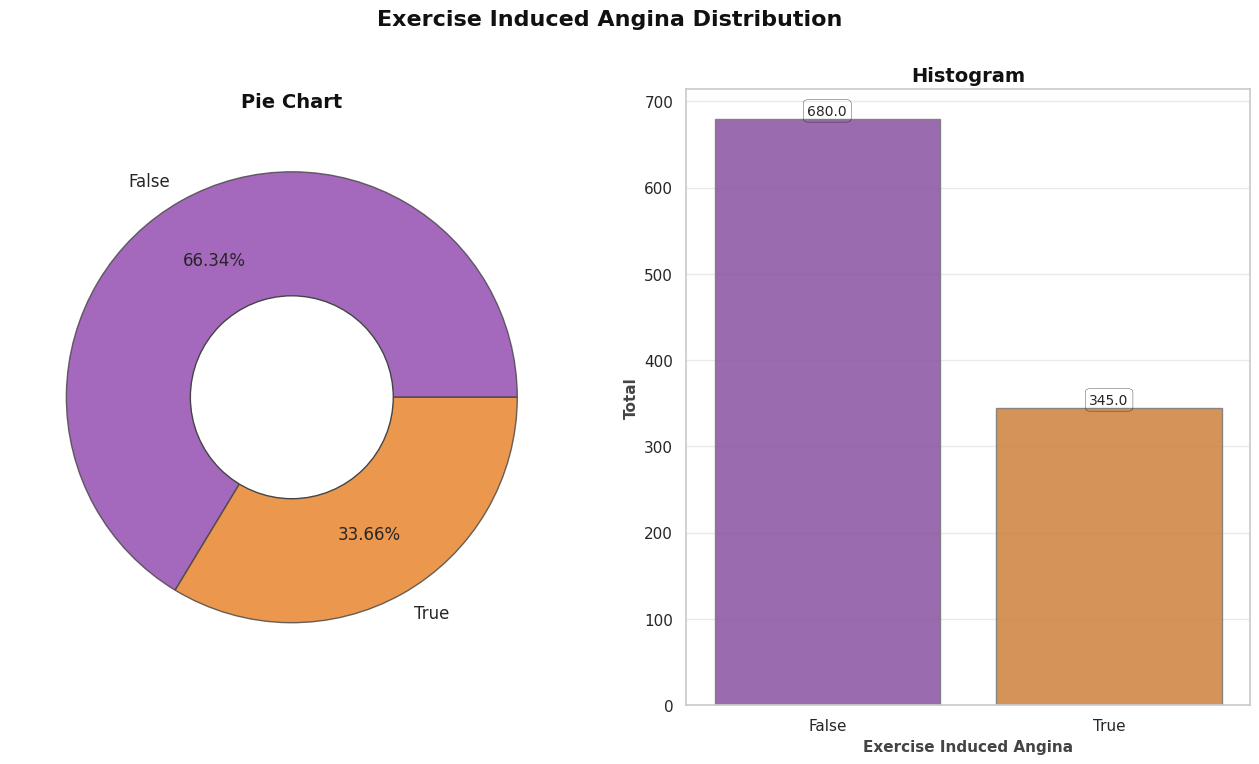

In [12]:
# I check exercise-induced angina because it can be an important signal for heart disease prediction.

colors=['#8E44AD', '#E67E22']
labels=['False', 'True']
order=df['exang'].value_counts().index

# Size for Both Figures
plt.figure(figsize=(16, 8))
plt.suptitle('Exercise Induced Angina Distribution', fontweight='heavy',
             fontsize=16, fontfamily='sans-serif', color='#111111')

# Pie Chart
plt.subplot(1,2,1)
plt.title('Pie Chart', fontweight='bold', fontsize=14, fontfamily='sans-serif',
          color='#111111')
plt.pie(df['exang'].value_counts(), labels=labels, colors=colors,
        wedgeprops=dict(alpha=0.8, edgecolor='#444444'), autopct='%.2f%%',
        pctdistance=0.7, textprops={'fontsize':12})
centre=plt.Circle((0, 0), 0.45, fc='white', edgecolor='#444444')
plt.gcf().gca().add_artist(centre)

# Histogram
countplt = plt.subplot(1, 2, 2)
plt.title('Histogram', fontweight='bold', fontsize=14, fontfamily='sans-serif',
          color='#111111')
ax = sns.countplot(x='exang', data=df, palette=colors, order=order,
                   edgecolor='#777777', alpha=0.85)
for rect in ax.patches:
    ax.text (rect.get_x()+rect.get_width()/2,
             rect.get_height()+4.25,rect.get_height(),
             horizontalalignment='center', fontsize=10,
             bbox=dict(facecolor='none', edgecolor='#111111', linewidth=0.25,
                       boxstyle='round'))

plt.xlabel('Exercise Induced Angina', fontweight='bold', fontsize=11,
           fontfamily='sans-serif', color='#444444')
plt.ylabel('Total', fontweight='bold', fontsize=11, fontfamily='sans-serif',
           color='#444444')
plt.xticks([0, 1], labels)
plt.grid(axis='y', alpha=0.4)
countplt

# Count Categorical Labels without dropping null values
print('\033[1m'+'.: Exercise Induced Angina Total :.'+'\033[0m')
df.exang.value_counts(dropna=False)

**Chart analysis:** Most patients do not have exercise-induced angina, but the positive group is still large enough to be useful. This feature may help distinguish symptomatic patterns related to heart disease.


This cell checks the slope of the peak exercise ST segment. Categories 1 and 2 dominate the dataset, while category 0 is much smaller. This is another categorical feature that should be encoded before modeling.


.: Slope Total :.


,count
slope,
1,482
2,469
0,74


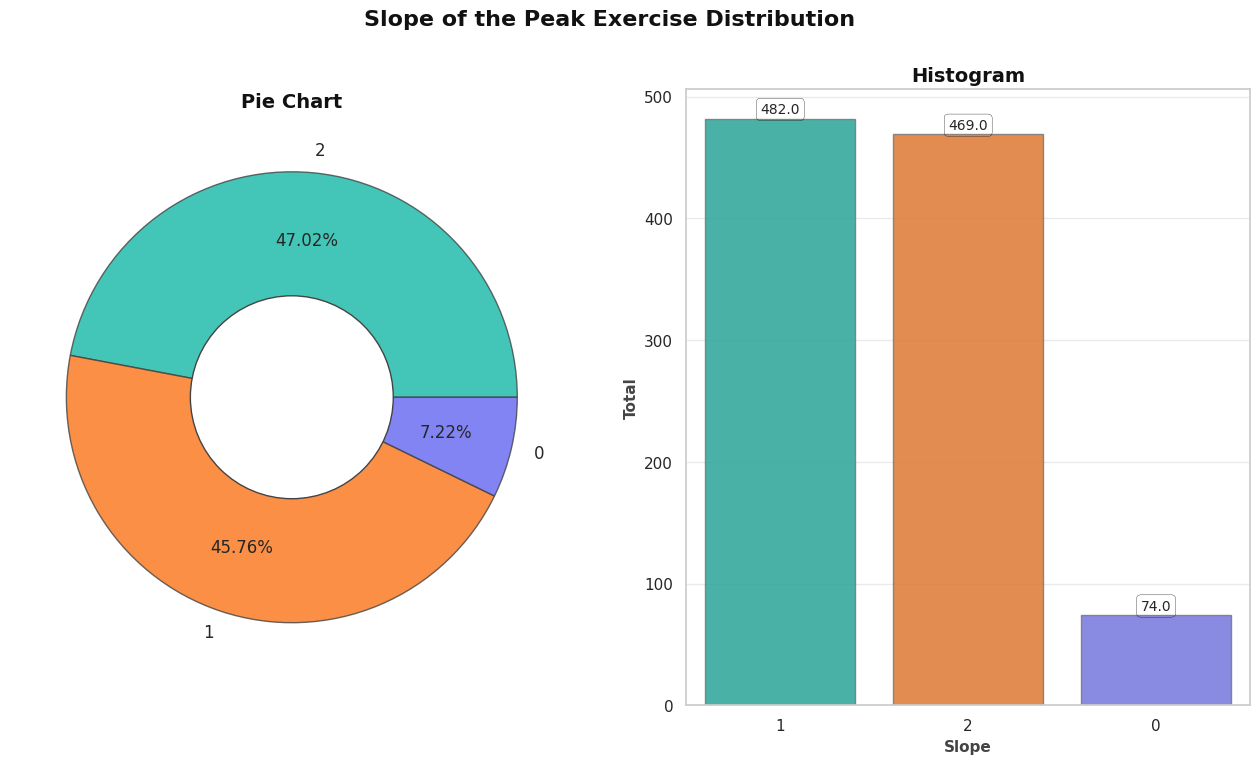

In [13]:
# I inspect the slope categories because they describe the shape of the ST segment during exercise.
colors=['#14B8A6', '#F97316', '#6366F1']
labels=['2', '1', '0']
order=df['slope'].value_counts().index

# Size for Both Figures
plt.figure(figsize=(16, 8))
plt.suptitle('Slope of the Peak Exercise Distribution', fontweight='heavy',
             fontsize=16, fontfamily='sans-serif', color='#111111')

# Pie Chart
plt.subplot(1, 2, 1)
plt.title('Pie Chart', fontweight='bold', fontsize=14,
          fontfamily='sans-serif', color='#111111')
plt.pie(df['slope'].value_counts(), labels=labels, colors=colors,
        wedgeprops=dict(alpha=0.8, edgecolor='#444444'), autopct='%.2f%%',
        pctdistance=0.7, textprops={'fontsize':12})
centre=plt.Circle((0, 0), 0.45, fc='white', edgecolor='#444444')
plt.gcf().gca().add_artist(centre)


# Histogram
countplt = plt.subplot(1, 2, 2)
plt.title('Histogram', fontweight='bold', fontsize=14, fontfamily='sans-serif',
          color='#111111')
ax = sns.countplot(x='slope', data=df, palette=colors, order=order,
                   edgecolor='#777777', alpha=0.85)
for rect in ax.patches:
    ax.text (rect.get_x()+rect.get_width()/2,
             rect.get_height()+4.25,rect.get_height(),
             horizontalalignment='center', fontsize=10,
             bbox=dict(facecolor='none', edgecolor='#111111', linewidth=0.25,
                       boxstyle='round'))

plt.xlabel('Slope', fontweight='bold', fontsize=11, fontfamily='sans-serif',
           color='#444444')
plt.ylabel('Total', fontweight='bold', fontsize=11, fontfamily='sans-serif',
           color='#444444')
plt.grid(axis='y', alpha=0.4)
countplt

# Count Categorical Labels without dropping null values
print('\033[1m'+'.: Slope Total :.'+'\033[0m')
df.slope.value_counts(dropna=False)

**Chart analysis:** Slope categories 1 and 2 are the main groups. Because the categories are not naturally continuous, one-hot encoding later is a better choice than treating them as normal numbers.


The number of major vessels (`ca`) is strongly skewed toward 0 vessels. The output shows **578 records with ca = 0**, while higher values are much less frequent. This feature is important because it is directly related to cardiovascular condition.


.: Number of Major Vessels Total :.


,count
ca,
0,578
1,226
2,134
3,69
4,18


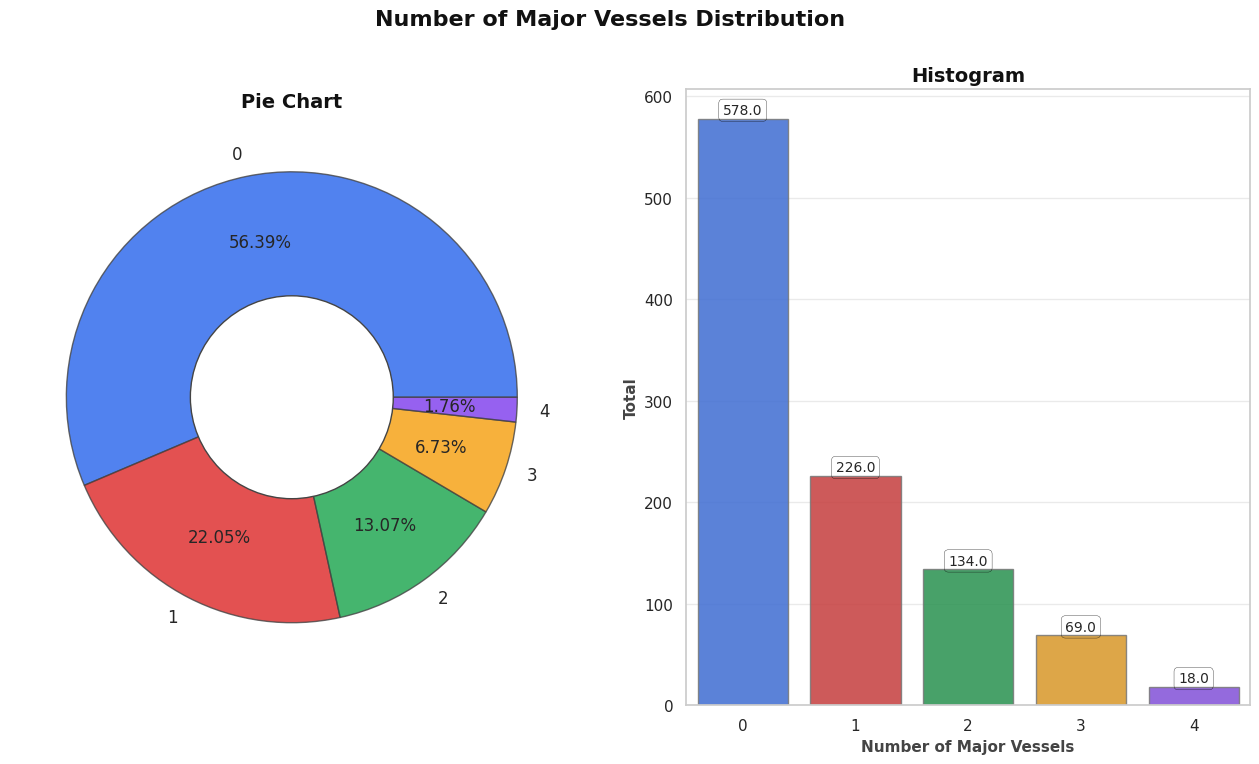

In [14]:
# I visualize the number of major vessels because it is usually a strong diagnostic feature.
colors=['#2563EB', '#DC2626', '#16A34A', '#F59E0B', '#7C3AED']
labels=['0', '1', '2', '3', '4']
order=df['ca'].value_counts().index

# Size for Both Figures
plt.figure(figsize=(16, 8))
plt.suptitle('Number of Major Vessels Distribution', fontweight='heavy',
             fontsize=16, fontfamily='sans-serif', color='#111111')

# Pie Chart
plt.subplot(1,2,1)
plt.title('Pie Chart', fontweight='bold', fontsize=14, fontfamily='sans-serif',
          color='#111111')
plt.pie(df['ca'].value_counts(), labels=labels, colors=colors,
        wedgeprops=dict(alpha=0.8, edgecolor='#444444'),
        autopct='%.2f%%', pctdistance=0.7, textprops={'fontsize':12})

centre=plt.Circle((0, 0), 0.45, fc='white', edgecolor='#444444')
plt.gcf().gca().add_artist(centre)

# Histogram
countplt = plt.subplot(1, 2, 2)
plt.title('Histogram', fontweight='bold', fontsize=14, fontfamily='sans-serif',
          color='#111111')
ax = sns.countplot(x='ca', data=df, palette=colors, order=order,
                   edgecolor='#777777', alpha=0.85)
for rect in ax.patches:
    ax.text (rect.get_x()+rect.get_width()/2,
             rect.get_height()+4.25,rect.get_height(),
             horizontalalignment='center', fontsize=10,
             bbox=dict(facecolor='none', edgecolor='#111111', linewidth=0.25,
                       boxstyle='round'))

plt.xlabel('Number of Major Vessels', fontweight='bold', fontsize=11,
           fontfamily='sans-serif', color='#444444')
plt.ylabel('Total', fontweight='bold', fontsize=11, fontfamily='sans-serif',
           color='#444444')
plt.grid(axis='y', alpha=0.4)
countplt

# Count Categorical Labels without dropping null values
print('\033[1m'+'.: Number of Major Vessels Total :.'+'\033[0m')
df.ca.value_counts(dropna=False)

**Chart analysis:** `ca = 0` is the largest group. Later, the target comparison also suggests that `ca` has a meaningful relationship with heart disease status, so this feature is likely important.


This plot shows the `thal` feature. Most samples are in categories 2 and 3, while categories 0 and 1 are much less frequent. Since `thal` is categorical, it should not be treated as a normal continuous number.


.: "thal" Total :.


,count
thal,
2,544
3,410
1,64
0,7


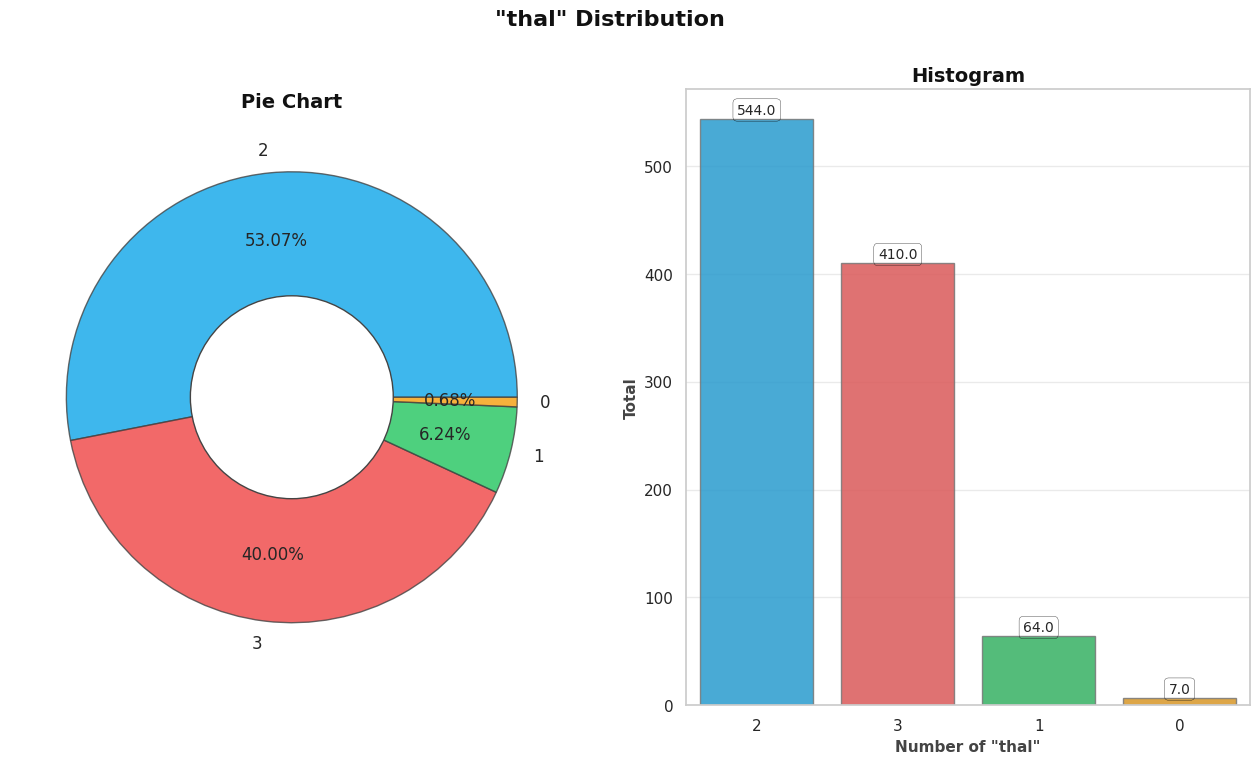

In [15]:
# I inspect thalassemia categories because they are categorical and may carry useful prediction signal.
colors=['#0EA5E9', '#EF4444', '#22C55E', '#F59E0B']
labels=['2', '3', '1', '0']
order=df['thal'].value_counts().index

# Size for Both Figures
plt.figure(figsize=(16,8))
plt.suptitle('"thal" Distribution', fontweight='heavy', fontsize=16,
             fontfamily='sans-serif', color='#111111')

# Pie Chart
plt.subplot(1,2,1)
plt.title('Pie Chart', fontweight='bold', fontsize=14, fontfamily='sans-serif',
          color='#111111')
plt.pie(df['thal'].value_counts(), labels=labels, colors=colors,
        wedgeprops=dict(alpha=0.8, edgecolor='#444444'),
        autopct='%.2f%%', pctdistance=0.7, textprops={'fontsize':12})

centre=plt.Circle((0, 0), 0.45, fc='white', edgecolor='#444444')
plt.gcf().gca().add_artist(centre)

# Histogram
countplt = plt.subplot(1, 2, 2)
plt.title('Histogram', fontweight='bold', fontsize=14, fontfamily='sans-serif',
          color='#111111')
ax = sns.countplot(x='thal', data=df, palette=colors, order=order,
                   edgecolor='#777777', alpha=0.85)
for rect in ax.patches:
    ax.text (rect.get_x()+rect.get_width()/2,
             rect.get_height()+4.25,rect.get_height(),
             horizontalalignment='center', fontsize=10,
             bbox=dict(facecolor='none', edgecolor='#111111', linewidth=0.25,
                       boxstyle='round'))

plt.xlabel('Number of "thal"', fontweight='bold', fontsize=11,
           fontfamily='sans-serif', color='#444444')
plt.ylabel('Total', fontweight='bold', fontsize=11, fontfamily='sans-serif',
           color='#444444')
plt.grid(axis='y', alpha=0.4)
countplt

# Count Categorical Labels without dropping null values
print('\033[1m'+'.: "thal" Total :.'+'\033[0m')
df.thal.value_counts(dropna=False)

**Chart analysis:** Most `thal` values are concentrated in categories 2 and 3. Since categories 0 and 1 are rare, their effect on the model should be interpreted with caution.


This plot checks the target variable. The two classes are almost balanced: **526 positive** and **499 negative** cases. This is good for basic accuracy evaluation because the model cannot get a high score simply by always predicting one class.


.: Heart Diseases Status (target) Total :.


,count
target,
1,526
0,499


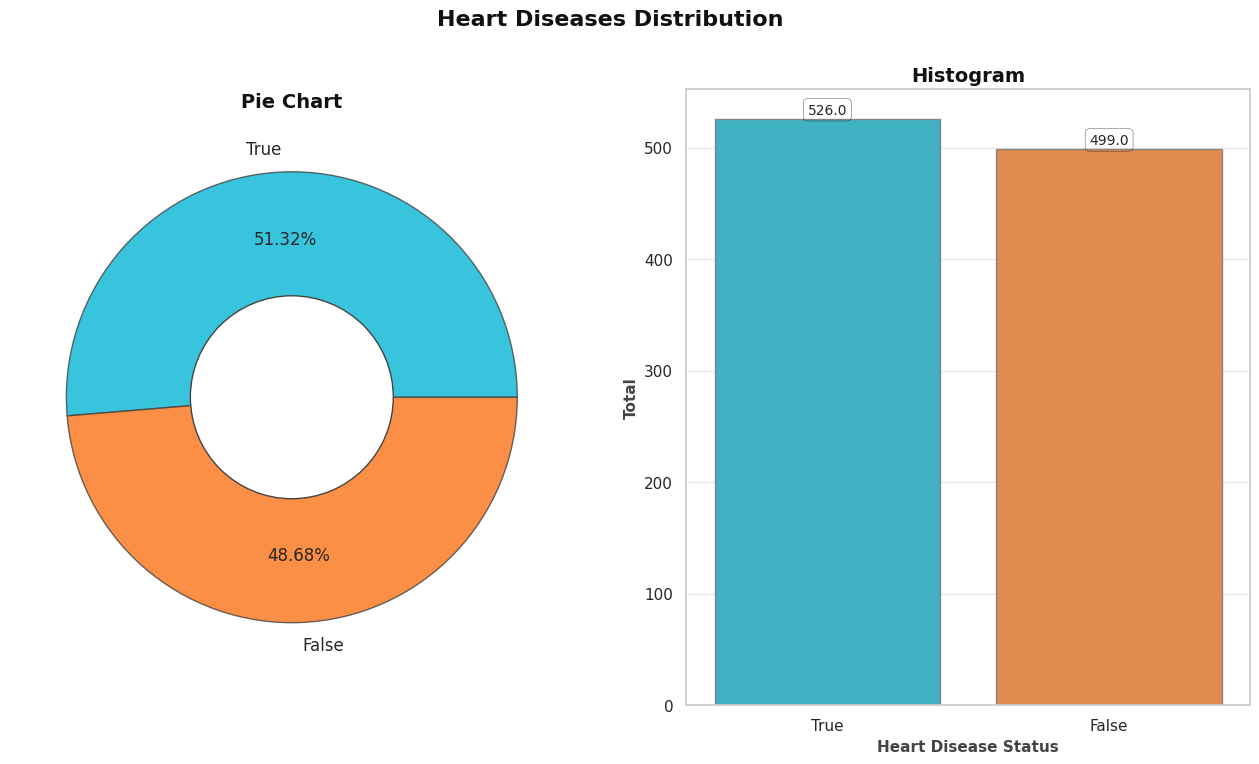

In [16]:
# I check the target distribution before modeling, because class imbalance can strongly affect accuracy.
colors=['#06B6D4', '#F97316']
labels=['True', 'False']
order=df['target'].value_counts().index

# Size for Both Figures
plt.figure(figsize=(16,8))
plt.suptitle('Heart Diseases Distribution', fontweight='heavy',
             fontsize=16, fontfamily='sans-serif', color='#111111')

# Pie Chart
plt.subplot(1, 2, 1)
plt.title('Pie Chart', fontweight='bold', fontsize=14, fontfamily='sans-serif',
          color='#111111')
plt.pie(df['target'].value_counts(), labels=labels, colors=colors,
        wedgeprops=dict(alpha=0.8, edgecolor='#444444'), autopct='%.2f%%',
        pctdistance=0.7, textprops={'fontsize':12})
centre=plt.Circle((0, 0), 0.45, fc='white', edgecolor='#444444')
plt.gcf().gca().add_artist(centre)

# Histogram
countplt = plt.subplot(1, 2, 2)
plt.title('Histogram', fontweight='bold', fontsize=14, fontfamily='sans-serif',
          color='#111111')
ax = sns.countplot(x='target', data=df, palette=colors, order=order,
                   edgecolor='#777777', alpha=0.85)
for rect in ax.patches:
    ax.text (rect.get_x()+rect.get_width()/2,
             rect.get_height()+4.25,rect.get_height(),
             horizontalalignment='center', fontsize=10,
             bbox=dict(facecolor='none', edgecolor='#111111', linewidth=0.25,
                       boxstyle='round'))

plt.xlabel('Heart Disease Status', fontweight='bold', fontsize=11,
           fontfamily='sans-serif', color='#444444')
plt.ylabel('Total', fontweight='bold', fontsize=11, fontfamily='sans-serif',
           color='#444444')
plt.xticks([0, 1], labels)
plt.grid(axis='y', alpha=0.4)
countplt

# Count Categorical Labels without dropping null values
print('\033[1m'+'.: Heart Diseases Status (target) Total :.'+'\033[0m')
df.target.value_counts(dropna=False)

**Chart analysis:** The target is nearly balanced, so accuracy is a reasonable first metric. Still, for a stronger medical-style evaluation, precision, recall, F1-score, and a confusion matrix would also be useful.


## 5. Exploratory Data Analysis: numerical features

This descriptive statistics table summarizes the numerical columns. I use it to compare ranges and identify variables that may need scaling. For example, cholesterol and resting blood pressure have much larger numeric ranges than `oldpeak`, so scaling is important before distance-based models.


In [17]:
# This table summarizes the numerical columns and helps identify possible scale differences or outliers.
# Descriptive Statistics
df.select_dtypes(exclude='object').describe().T.style.background_gradient(cmap='Greens').set_properties(**{'font-family': 'Segoe UI'})

,count,mean,std,min,25%,50%,75%,max
age,1025.000000,54.434146,9.072290,29.000000,48.000000,56.000000,61.000000,77.000000
trestbps,1025.000000,131.611707,17.516718,94.000000,120.000000,130.000000,140.000000,200.000000
chol,1025.000000,246.000000,51.592510,126.000000,211.000000,240.000000,275.000000,564.000000
thalach,1025.000000,149.114146,23.005724,71.000000,132.000000,152.000000,166.000000,202.000000
oldpeak,1025.000000,1.071512,1.175053,0.000000,0.000000,0.800000,1.800000,6.200000
target,1025.000000,0.513171,0.500070,0.000000,0.000000,1.000000,1.000000,1.000000


The age distribution is slightly left-skewed, but not extremely. Most patients are middle-aged or older, which is expected for a heart disease dataset. The box plot also helps reveal whether there are unusual age values.


.: Age Column Skewness & Kurtosis :.
Skewness: -0.249
Kurtosis: -0.526




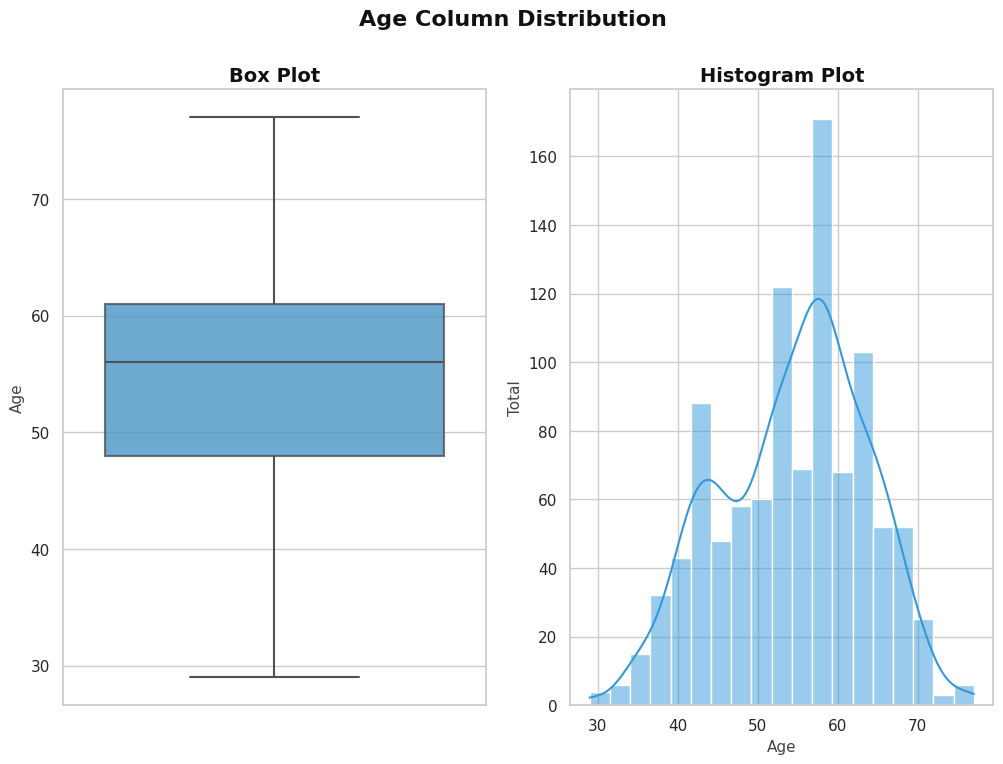

In [18]:
# I examine the age distribution to understand the age range and whether it is skewed.
var = 'age'
color = '#3498DB'
title_color = '#111111'
label_color = '#444444'

fig = plt.figure(figsize=(12, 8))

# Skewness & Kurtosis
print('\033[1m'+'.: Age Column Skewness & Kurtosis :.'+'\033[0m')
print('Skewness:'+'\033[1m {:.3f}'.format(df[var].skew(axis=0, skipna=True)))
print('\033[0m'+'Kurtosis:'+'\033[1m {:.3f}'.format(df[var].kurt(axis=0, skipna=True)))
print('\n')

# General Title
fig.suptitle('Age Column Distribution', fontweight='bold', fontsize=16,
             fontfamily='sans-serif', color=title_color)
fig.subplots_adjust(top=0.88)

# Box Plot
ax_1 = fig.add_subplot(1, 2, 1)
plt.title('Box Plot', fontweight='bold', fontsize=14, fontfamily='sans-serif',
          color=title_color)
sns.boxplot(data=df, y=var, color=color, boxprops=dict(alpha=0.8), linewidth=1.5)
plt.ylabel('Age', fontweight='regular', fontsize=11, fontfamily='sans-serif',
           color=label_color)

# Histogram
ax_2 = fig.add_subplot(1, 2, 2)
plt.title('Histogram Plot', fontweight='bold', fontsize=14,
          fontfamily='sans-serif', color=title_color)
sns.histplot(data=df, x=var, kde=True, color=color)
plt.xlabel('Age', fontweight='regular', fontsize=11,
           fontfamily='sans-serif', color=label_color)
plt.ylabel('Total', fontweight='regular', fontsize=11, fontfamily='sans-serif',
           color=label_color)

plt.show()

**Distribution analysis:** Age has mild negative skewness and no extreme kurtosis. This means the age distribution is fairly regular, with most samples around the middle-to-older age range.


Resting blood pressure is moderately right-skewed. This means most values are in a normal range, but there are some higher blood-pressure values that stretch the distribution to the right.


.: Resting Blood Pressure Column Skewness & Kurtosis :.
Skewness: 0.740
Kurtosis: 0.991




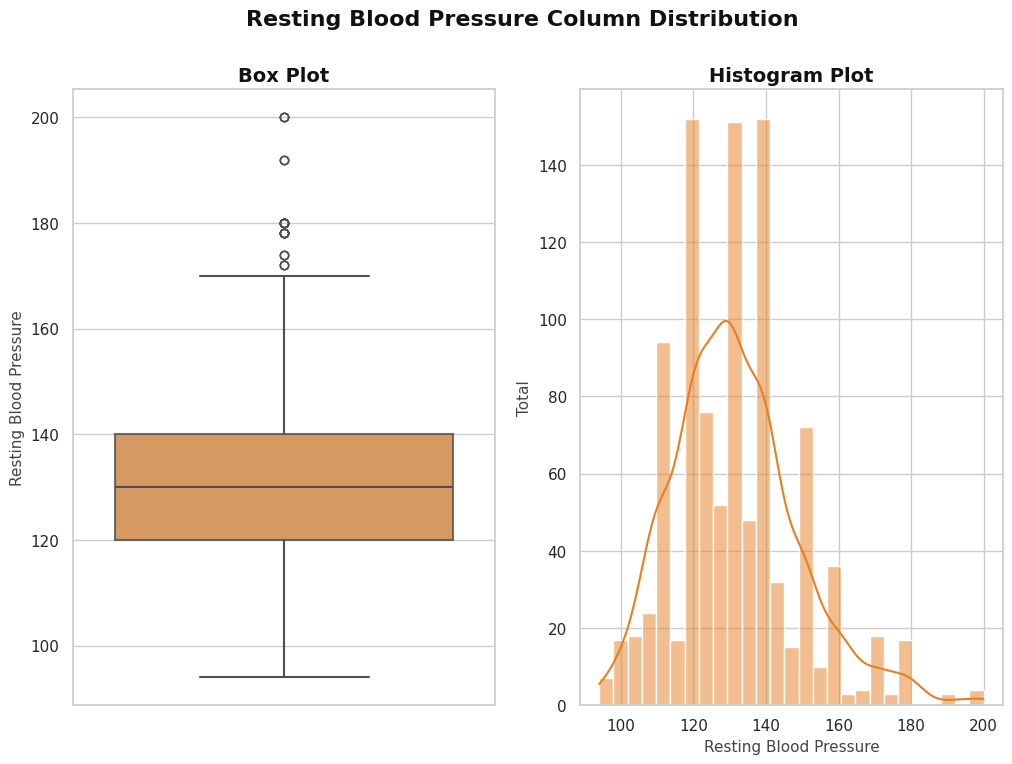

In [19]:
# I examine resting blood pressure to check spread, skewness, and possible high-value outliers.
var = 'trestbps'
color = '#E67E22'
title_color = '#111111'
label_color = '#444444'

fig = plt.figure(figsize=(12, 8))

# Skewness & Kurtosis
print('\033[1m'+'.: Resting Blood Pressure Column Skewness & Kurtosis :.'+'\033[0m')
print('Skewness:'+'\033[1m {:.3f}'.format(df[var].skew(axis=0, skipna=True)))
print('\033[0m'+'Kurtosis:'+'\033[1m {:.3f}'.format(df[var].kurt(axis=0, skipna=True)))
print('\n')

# General Title
fig.suptitle('Resting Blood Pressure Column Distribution', fontweight='bold',
             fontsize=16, fontfamily='sans-serif', color=title_color)
fig.subplots_adjust(top=0.88)

# Box Plot
ax_1 = fig.add_subplot(1, 2, 1)
plt.title('Box Plot', fontweight='bold', fontsize=14, fontfamily='sans-serif',
          color=title_color)
sns.boxplot(data=df, y=var, color=color, boxprops=dict(alpha=0.8), linewidth=1.5)
plt.ylabel('Resting Blood Pressure', fontweight='regular', fontsize=11,
           fontfamily='sans-serif', color=label_color)

# Histogram
ax_2 = fig.add_subplot(1, 2, 2)
plt.title('Histogram Plot', fontweight='bold', fontsize=14,
          fontfamily='sans-serif', color=title_color)
sns.histplot(data=df, x=var, kde=True, color=color)
plt.xlabel('Resting Blood Pressure', fontweight='regular', fontsize=11,
           fontfamily='sans-serif', color=label_color)
plt.ylabel('Total', fontweight='regular', fontsize=11,
           fontfamily='sans-serif', color=label_color)

plt.show()

**Distribution analysis:** Resting blood pressure is right-skewed, meaning some patients have higher values than the majority. These high values can influence linear or distance-based models if the data is not scaled.


Cholesterol has stronger right skewness and high kurtosis. This suggests there are some large cholesterol values or outliers. Models such as trees are less sensitive to this, but scaling is still useful for KNN, SVM, and logistic regression.


.: Serum Cholesterol Column Skewness & Kurtosis :.
*********************************************
Skewness: 1.074
Kurtosis: 3.997




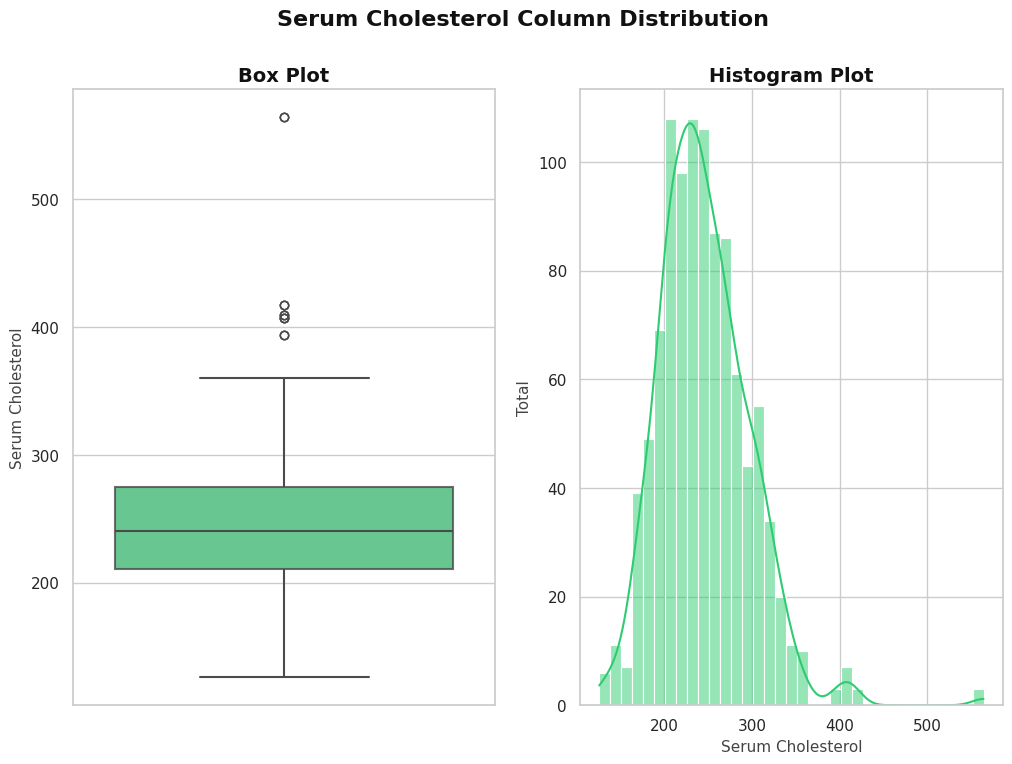

In [20]:
# I examine cholesterol because it has a wider range and may contain extreme values.
var = 'chol'
color = '#2ECC71'
title_color = '#111111'
label_color = '#444444'

fig = plt.figure(figsize=(12, 8))

# Skewness & Kurtosis
print('\033[1m'+'.: Serum Cholesterol Column Skewness & Kurtosis :.'+'\033[0m')
print('*' * 45)
print('Skewness:'+'\033[1m {:.3f}'.format(df[var].skew(axis=0, skipna=True)))
print('\033[0m'+'Kurtosis:'+'\033[1m {:.3f}'.format(df[var].kurt(axis=0, skipna=True)))
print('\n')

# General Title
fig.suptitle('Serum Cholesterol Column Distribution', fontweight='bold',
             fontsize=16, fontfamily='sans-serif', color=title_color)
fig.subplots_adjust(top=0.88)

# Box Plot
ax_1 = fig.add_subplot(1, 2, 1)
plt.title('Box Plot', fontweight='bold', fontsize=14,
          fontfamily='sans-serif', color=title_color)
sns.boxplot(data=df, y=var, color=color, boxprops=dict(alpha=0.8), linewidth=1.5)
plt.ylabel('Serum Cholesterol', fontweight='regular', fontsize=11,
           fontfamily='sans-serif', color=label_color)

# Histogram
ax_2 = fig.add_subplot(1, 2, 2)
plt.title('Histogram Plot', fontweight='bold', fontsize=14,
          fontfamily='sans-serif', color=title_color)
sns.histplot(data=df, x=var, kde=True, color=color)
plt.xlabel('Serum Cholesterol', fontweight='regular', fontsize=11,
           fontfamily='sans-serif', color=label_color)
plt.ylabel('Total', fontweight='regular', fontsize=11,
           fontfamily='sans-serif', color=label_color)

plt.show()

**Distribution analysis:** Cholesterol is clearly right-skewed and has high kurtosis, suggesting extreme values. This supports the decision to scale features and also explains why robust evaluation is important.


Maximum heart rate is slightly left-skewed. The distribution suggests many patients have moderate-to-high maximum heart rates, while fewer patients have very low values. This feature is useful because lower maximum heart rate can be associated with higher risk in this dataset.


.: Maximum Heart Rate Column Skewness & Kurtosis :.
Skewness: -0.514
Kurtosis: -0.089




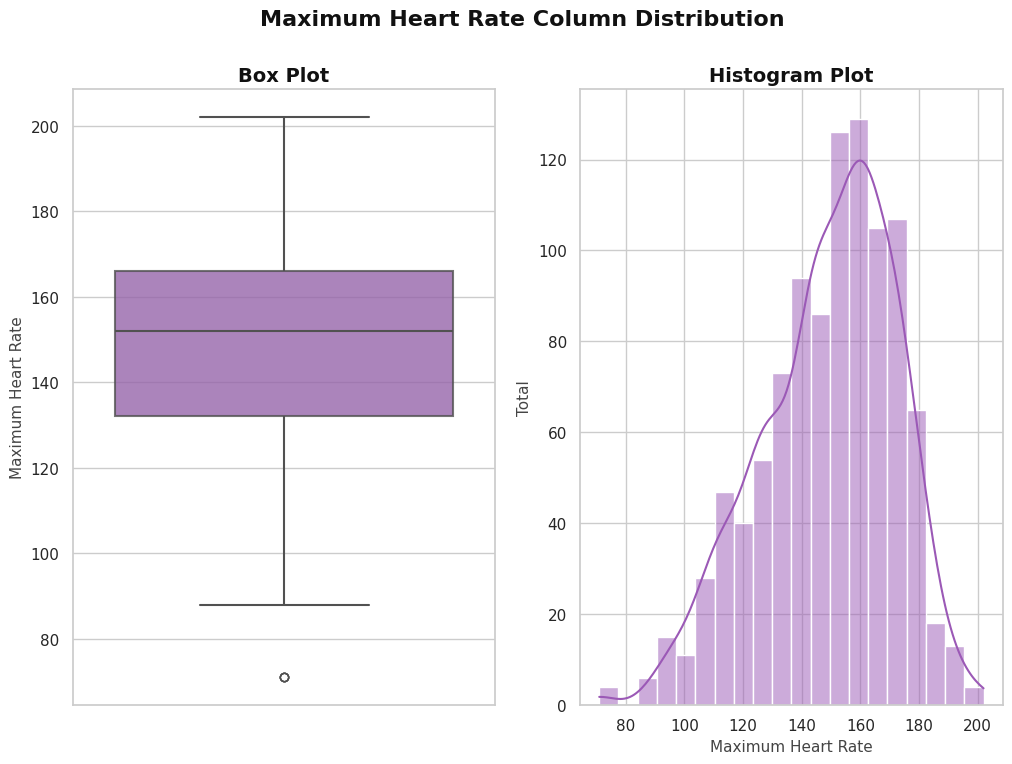

In [21]:
# I examine maximum heart rate because it is likely related to both age and heart disease status.
var = 'thalach'
color = '#9B59B6'
title_color = '#111111'
label_color = '#444444'

fig = plt.figure(figsize=(12, 8))

# Skewness & Kurtosis
print('\033[1m'+'.: Maximum Heart Rate Column Skewness & Kurtosis :.'+'\033[0m')
print('Skewness:'+'\033[1m {:.3f}'.format(df[var].skew(axis=0, skipna=True)))
print('\033[0m'+'Kurtosis:'+'\033[1m {:.3f}'.format(df[var].kurt(axis=0, skipna=True)))
print('\n')

# General Title
fig.suptitle('Maximum Heart Rate Column Distribution', fontweight='bold',
             fontsize=16, fontfamily='sans-serif', color=title_color)
fig.subplots_adjust(top=0.88)

# Box Plot
ax_1 = fig.add_subplot(1, 2, 1)
plt.title('Box Plot', fontweight='bold', fontsize=14,
          fontfamily='sans-serif', color=title_color)
sns.boxplot(data=df, y=var, color=color, boxprops=dict(alpha=0.8), linewidth=1.5)
plt.ylabel('Maximum Heart Rate', fontweight='regular', fontsize=11,
           fontfamily='sans-serif', color=label_color)

# Histogram
ax_2 = fig.add_subplot(1, 2, 2)
plt.title('Histogram Plot', fontweight='bold', fontsize=14,
          fontfamily='sans-serif', color=title_color)
sns.histplot(data=df, x=var, kde=True, color=color)
plt.xlabel('Maximum Heart Rate', fontweight='regular', fontsize=11,
           fontfamily='sans-serif', color=label_color)
plt.ylabel('Total', fontweight='regular', fontsize=11,
           fontfamily='sans-serif', color=label_color)

plt.show()

**Distribution analysis:** Maximum heart rate has mild negative skewness. It also appears useful in the scatter plot because it helps separate some target patterns when combined with age.


The `oldpeak` feature is right-skewed. Many patients have low oldpeak values, but a smaller number have much larger values. This feature may be informative because it measures ST depression induced by exercise.


.: "oldpeak" Column Skewness & Kurtosis :.
Skewness: 1.211
Kurtosis: 1.314




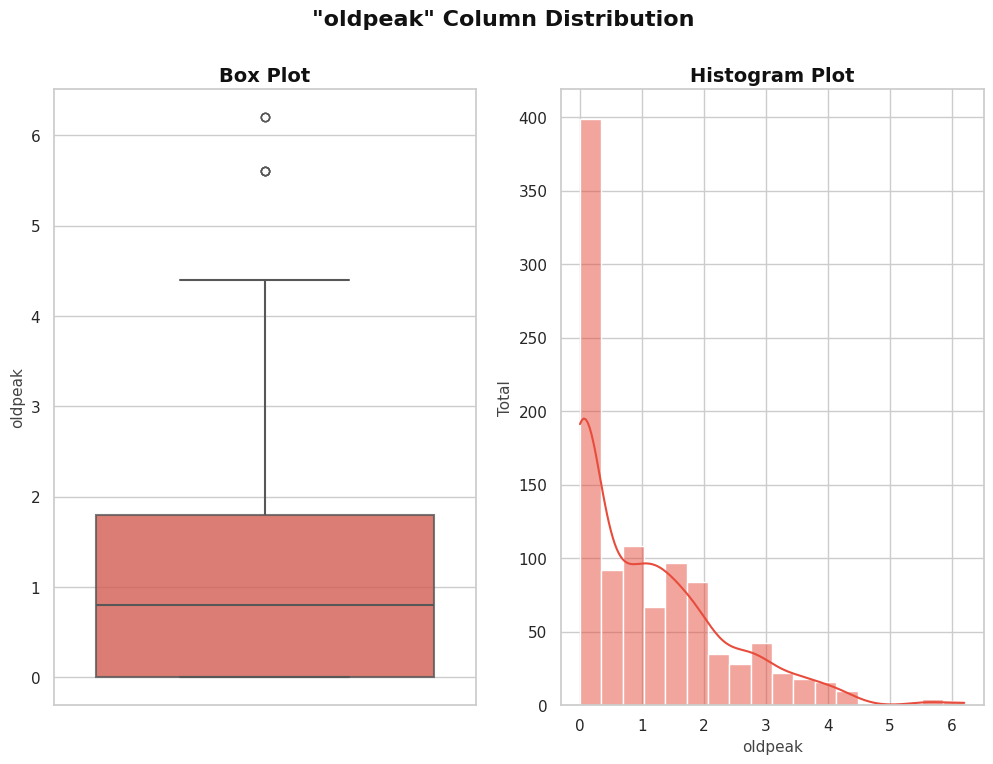

In [22]:
# I examine oldpeak because its distribution can affect models that rely on distance or linear boundaries.
var = 'oldpeak'
color = '#E74C3C'
title_color = '#111111'
label_color = '#444444'

fig = plt.figure(figsize=(12, 8))

# Skewness & Kurtosis
print('\033[1m'+'.: "oldpeak" Column Skewness & Kurtosis :.'+'\033[0m')
print('Skewness:'+'\033[1m {:.3f}'.format(df[var].skew(axis=0, skipna=True)))
print('\033[0m'+'Kurtosis:'+'\033[1m {:.3f}'.format(df[var].kurt(axis=0, skipna=True)))
print('\n')

# General Title
fig.suptitle('"oldpeak" Column Distribution', fontweight='bold',
             fontsize=16, fontfamily='sans-serif', color=title_color)
fig.subplots_adjust(top=0.88)

# Box Plot
ax_1 = fig.add_subplot(1, 2, 1)
plt.title('Box Plot', fontweight='bold', fontsize=14,
          fontfamily='sans-serif', color=title_color)
sns.boxplot(data=df, y=var, color=color, boxprops=dict(alpha=0.8), linewidth=1.5)
plt.ylabel('oldpeak', fontweight='regular', fontsize=11,
           fontfamily='sans-serif', color=label_color)

# Histogram
ax_2 = fig.add_subplot(1, 2, 2)
plt.title('Histogram Plot', fontweight='bold', fontsize=14,
          fontfamily='sans-serif', color=title_color)
sns.histplot(data=df, x=var, kde=True, color=color)
plt.xlabel('oldpeak', fontweight='regular', fontsize=11,
           fontfamily='sans-serif', color=label_color)
plt.ylabel('Total', fontweight='regular', fontsize=11,
           fontfamily='sans-serif', color=label_color)

plt.show()

**Distribution analysis:** `oldpeak` is right-skewed. Many values are close to zero, but higher values may contain important diagnostic signal for the classifier.


## 6. Relationship between features and target

This chart compares heart disease status by gender. It gives a more useful view than the gender distribution alone because it shows how the target is distributed inside each sex group. The important point is not only which group is larger, but whether the positive/negative class ratio changes between groups.


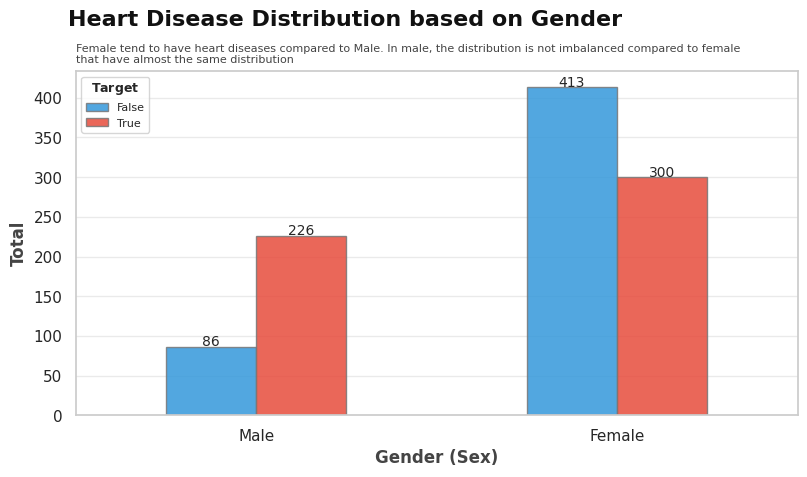

In [23]:
# This crosstab compares target labels across gender groups instead of looking at gender alone.
labels = ['False', 'True']
label_gender = np.array([0, 1])
label_gender2 = ['Male', 'Female']

colors = ['#3498DB', '#E74C3C']
edge_color = '#777777'
title_color = '#111111'
subtitle_color = '#444444'

# Creating Bar Chart
ax = pd.crosstab(df.sex, df.target).plot(
    kind='bar',
    figsize=(8, 5),
    color=colors,
    edgecolor=edge_color,
    alpha=0.85
)

# Add Values on Bars
for rect in ax.patches:
    ax.text(
        rect.get_x() + rect.get_width() / 2,
        rect.get_height() + 1.25,
        rect.get_height(),
        horizontalalignment='center',
        fontsize=10
    )

# Bar Chart Settings
plt.suptitle(
    'Heart Disease Distribution based on Gender',
    fontweight='heavy',
    x=0.065,
    y=0.98,
    ha='left',
    fontsize=16,
    fontfamily='sans-serif',
    color=title_color
)

plt.title(
    'Female tend to have heart diseases compared to Male. In male, the distribution is not imbalanced compared to female\nthat have almost the same distribution',
    fontsize=8,
    fontfamily='sans-serif',
    loc='left',
    color=subtitle_color
)

plt.tight_layout(rect=[0, 0.04, 1, 1.025])

plt.xlabel(
    'Gender (Sex)',
    fontfamily='sans-serif',
    fontweight='bold',
    color=subtitle_color
)

plt.ylabel(
    'Total',
    fontfamily='sans-serif',
    fontweight='bold',
    color=subtitle_color
)

plt.xticks(label_gender, label_gender2, rotation=0)
plt.grid(axis='y', alpha=0.4)
plt.grid(axis='x', alpha=0)

plt.legend(
    labels=labels,
    title='$\\bf{Target}$',
    fontsize=8,
    title_fontsize=9,
    loc='upper left',
    frameon=True
)

plt.show()

**Chart analysis:** The target distribution differs between gender groups, but this should not be overinterpreted because the dataset itself has more male samples. The chart is still useful because it shows that sex may contribute some predictive signal.


This chart compares the target with the number of major vessels. Patients with `ca = 0` appear more often in the positive target class, while values 1 to 3 are more associated with the negative class in this dataset. This makes `ca` one of the more useful features for prediction.


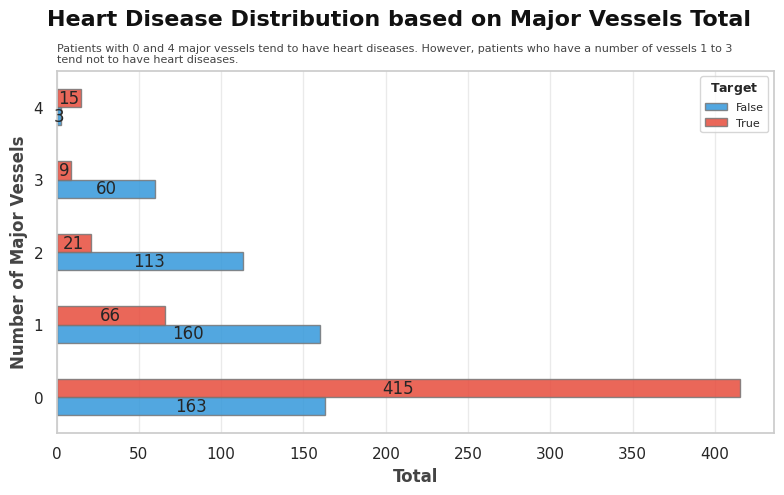

In [24]:
# This crosstab checks how the target changes with the number of major vessels.
labels = ['False', 'True']

colors = ['#3498DB', '#E74C3C']
edge_color = '#777777'
title_color = '#111111'
subtitle_color = '#444444'

# Creating Horizontal Bar Chart
ax = pd.crosstab(df.ca, df.target).plot(
    kind='barh',
    figsize=(8, 5),
    color=colors,
    edgecolor=edge_color,
    alpha=0.85
)

# Add Values on Bars
for rect in ax.patches:
    width, height = rect.get_width(), rect.get_height()
    x, y = rect.get_xy()
    ax.text(
        x + width / 2,
        y + height / 2,
        '{:.0f}'.format(width),
        horizontalalignment='center',
        verticalalignment='center'
    )

# Horizontal Bar Chart Settings
plt.suptitle(
    'Heart Disease Distribution based on Major Vessels Total',
    fontweight='heavy',
    x=0.069,
    y=0.98,
    ha='left',
    fontsize=16,
    fontfamily='sans-serif',
    color=title_color
)

plt.title(
    'Patients with 0 and 4 major vessels tend to have heart diseases. However, patients who have a number of vessels 1 to 3\ntend not to have heart diseases.',
    fontsize=8,
    fontfamily='sans-serif',
    loc='left',
    color=subtitle_color
)

plt.tight_layout(rect=[0, 0.04, 1, 1.025])

plt.xlabel(
    'Total',
    fontfamily='sans-serif',
    fontweight='bold',
    color=subtitle_color
)

plt.ylabel(
    'Number of Major Vessels',
    fontfamily='sans-serif',
    fontweight='bold',
    color=subtitle_color
)

plt.yticks(rotation=0)
plt.grid(axis='x', alpha=0.4)
plt.grid(axis='y', alpha=0)

plt.legend(
    labels=labels,
    title='$\\bf{Target}$',
    fontsize=8,
    frameon=True,
    title_fontsize=9,
    loc='upper right'
)

plt.show()

**Chart analysis:** The number of major vessels has a clear relationship with the target. In this dataset, `ca = 0` is more associated with the positive target class, while higher values are more associated with the negative class.


This scatter plot compares age and maximum heart rate, colored by target. It suggests that positive heart disease cases often appear with higher maximum heart-rate values in this dataset, especially across middle and older ages. The classes overlap, so these two features alone are not enough, but they still provide useful signal.


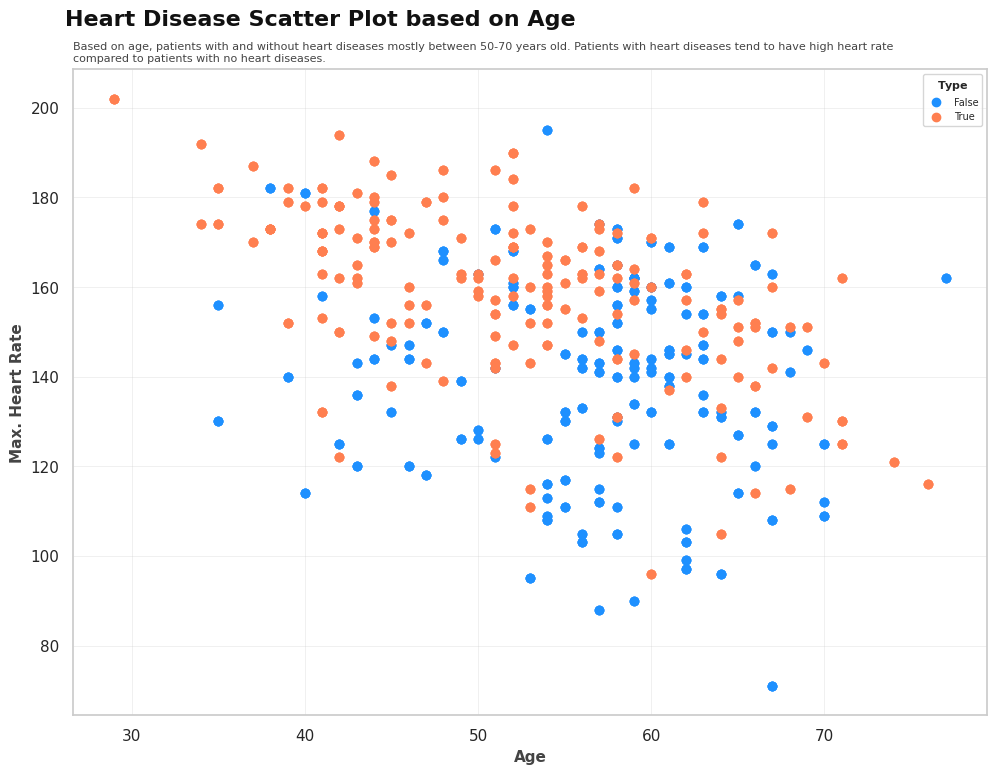

In [25]:
# This scatter plot helps compare age, maximum heart rate, and disease status at the same time.
plt.figure(figsize=(10, 8))

title_color = '#111111'
subtitle_color = '#444444'

plt.suptitle('Heart Disease Scatter Plot based on Age', fontweight='heavy',
             x=0.048, y=0.98, ha='left', fontsize='16', fontfamily='sans-serif',
             color=title_color)

plt.title('Based on age, patients with and without heart diseases mostly between 50-70 years old. Patients with heart diseases tend to have high heart rate\ncompared to patients with no heart diseases.',
          fontsize='8', fontfamily='sans-serif', loc='left', color=subtitle_color)

plt.tight_layout(rect=[0, 0.04, 1, 1.01])

# Creating Scatter Plot
plt.scatter(x=df.age[df.target==0], y=df.thalach[(df.target==0)], c='#1E90FF')
plt.scatter(x=df.age[df.target==1], y=df.thalach[(df.target==1)], c='#FF7F50')

# Scatter Plot Legend & Labels Settings
plt.legend(['False', 'True'], title='$\\bf{Type}$', fontsize='7',
           title_fontsize='8', loc='upper right', frameon=True)

plt.xlabel('Age', fontweight='bold', fontsize='11',
           fontfamily='sans-serif', color=subtitle_color)

plt.ylabel('Max. Heart Rate', fontweight='bold', fontsize='11',
           fontfamily='sans-serif', color=subtitle_color)

plt.ticklabel_format(style='plain', axis='both')
plt.grid(axis='both', alpha=0.4, lw=0.5)

plt.show()

**Chart analysis:** The classes overlap, but there is still a visible pattern between age, maximum heart rate, and target. This supports using multiple features together instead of relying on a single variable.


The correlation heatmap summarizes linear relationships between numerical variables. Strong correlation with the target is not the only way a feature can be useful, but the heatmap helps identify obvious relationships and possible redundancy between variables.


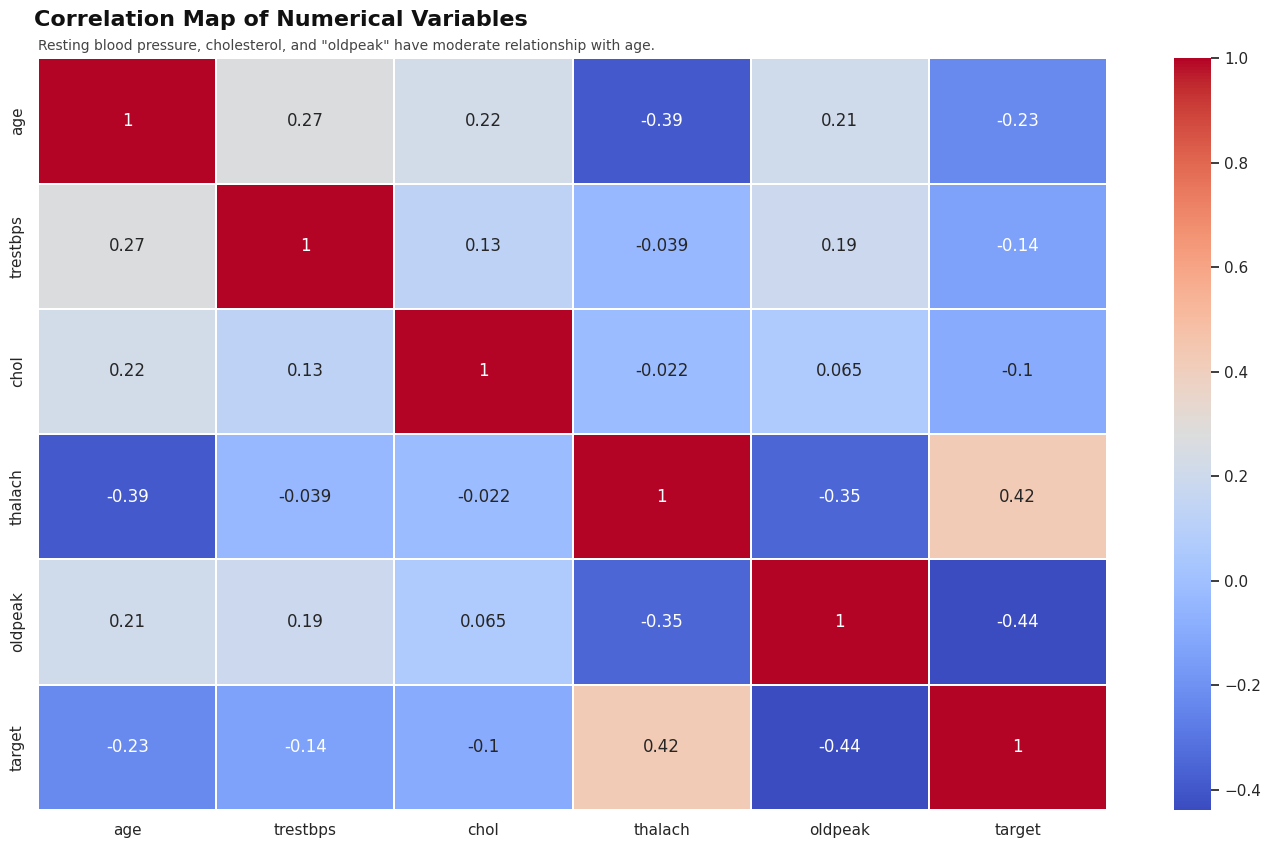

In [26]:
# The correlation heatmap gives a quick view of linear relationships between numerical variables.
# Correlation Map (Heatmap)
plt.figure(figsize=(14, 9))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', linewidths=0.1)

plt.suptitle('Correlation Map of Numerical Variables', fontweight='heavy',
             x=0.03, y=0.98, ha='left', fontsize='16', fontfamily='sans-serif',
             color='#111111')

plt.title('Resting blood pressure, cholesterol, and "oldpeak" have moderate relationship with age.',
          fontsize='10', fontfamily='sans-serif', loc='left', color='#444444')

plt.tight_layout(rect=[0, 0.04, 1, 1.01])
plt.show()

**Heatmap analysis:** The heatmap does not show one perfect predictor, which is expected. Heart disease prediction depends on several features together, so testing multiple ML models is a reasonable approach.


## 7. Preprocessing

Machine learning models need numerical input. For categorical features such as `cp`, `thal`, and `slope`, one-hot encoding creates separate binary columns for each category. This avoids forcing the model to interpret category numbers as ordered values.


In [27]:
# I one-hot encode selected categorical variables so the model does not treat categories as ordered numbers.
# Creating Dummy Variables for cp, thal and slope
cp = pd.get_dummies(df['cp'], prefix='cp', dtype=int)
thal = pd.get_dummies(df['thal'], prefix='thal', dtype=int)
slope = pd.get_dummies(df['slope'], prefix='slope', dtype=int)

# Merge Dummy Variables to Main Data Frame
frames = [df, cp, thal, slope]
df = pd.concat(frames, axis=1)

**Preprocessing note:** In a cleaner production pipeline, all categorical variables would usually be encoded consistently using `OneHotEncoder` inside a scikit-learn `Pipeline`. For this basic notebook, manual dummy variables are acceptable and easy to understand.


After adding dummy variables, I display the DataFrame again to verify that the new one-hot columns were added correctly. This is a simple but useful sanity check before training.


In [28]:
# I display the updated DataFrame to confirm that the dummy variables were added correctly.
df.head().style.background_gradient(cmap='PuRd').hide().set_properties(**{'font-family': 'Segoe UI'})

age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,cp_0,cp_1,cp_2,cp_3,thal_0,thal_1,thal_2,thal_3,slope_0,slope_1,slope_2
52,1,0,125,212,0,1,168,0,1.000000,2,2,3,0,1,0,0,0,0,0,0,1,0,0,1
53,1,0,140,203,1,0,155,1,3.100000,0,0,3,0,1,0,0,0,0,0,0,1,1,0,0
70,1,0,145,174,0,1,125,1,2.600000,0,0,3,0,1,0,0,0,0,0,0,1,1,0,0
61,1,0,148,203,0,1,161,0,0.000000,2,1,3,0,1,0,0,0,0,0,0,1,0,0,1
62,0,0,138,294,1,1,106,0,1.900000,1,3,2,0,1,0,0,0,0,0,1,0,0,1,0


Here I separate the dataset into `x` and `y`. The variable `x` contains all input features, while `y` contains the target label that the model should predict.


In [29]:
# I separate the input features from the target label before training the models.
x = df.drop(['target'], axis=1)
y = df['target']

Feature scaling is applied with Min-Max scaling, which transforms each feature into a similar numeric range. This is especially important for KNN and SVM because they depend on distances or margins, and large-scale features could otherwise dominate the model.


In [30]:
# I scale all feature values to a common range, which is especially helpful for KNN, SVM, and logistic regression.
# I keep an unscaled copy for cross-validation later. In cross-validation, scaling should happen inside each fold.
x_unscaled = x.copy()
x = MinMaxScaler().fit_transform(x)

The dataset is split into training and testing parts. The model learns from the training set, and the test set is used only for evaluation. This gives a better estimate of performance on unseen data than evaluating on the training data.


In [31]:
# I split the data into training and testing sets so the models are evaluated on unseen examples.
# Splitting Dataset into 80:20
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=4)

**Evaluation note:** Because the result depends on one random train/test split, a stronger version of the project could use cross-validation. Cross-validation would make the reported performance more stable.


## 8. Model training and evaluation




### Logistic Regression
Logistic Regression is used as a strong baseline. It is simple, fast, and often performs well on tabular binary classification problems. Here, L1 regularization is used, which can reduce the effect of less useful features.


In [32]:
# Logistic Regression is a simple linear baseline and is useful for comparison with more flexible models.
# Applying Logistic Regression
LRclassifier = LogisticRegression(max_iter=1000, random_state=1, solver='liblinear', penalty='l1')
LRclassifier.fit(x_train, y_train)

y_pred_LR = LRclassifier.predict(x_test)


The Logistic Regression model achieves **84.39% accuracy**. This is a solid baseline and suggests that the relationship between the features and target is partly captured by a linear decision boundary.


In [33]:
# I calculate accuracy to measure the percentage of correct predictions on the test set.
# LR Accuracy
LRAcc = accuracy_score(y_pred_LR, y_test)
print('.:. Logistic Regression Accuracy:'+'\033[1m {:.2f}%'.format(LRAcc*100)+' .:.')




.:. Logistic Regression Accuracy: 84.39% .:.


**Model analysis:** Logistic Regression is a good baseline here. Its accuracy shows that a relatively simple model can already learn useful structure from the features.


### K-Nearest Neighbors

K-Nearest Neighbors classifies a test example based on the labels of nearby training examples. Since KNN depends heavily on feature distance, the earlier Min-Max scaling step is important.


In [34]:
# KNN predicts based on nearby training examples, so scaling the features before this step is important.
# Applying KNN

KNNClassifier = KNeighborsClassifier(n_neighbors=3)
KNNClassifier.fit(x_train, y_train)

y_pred_KNN = KNNClassifier.predict(x_test)

KNN achieves **95.61% accuracy**, which is the highest score in this notebook. This suggests that similar patients in the scaled feature space often have the same target label. However, because this dataset is relatively small and may contain repeated or very similar rows, this high accuracy should be interpreted carefully.


In [35]:
# I record KNN accuracy so it can be compared with the other classifiers later.
# KNN Accuracy
KNNAcc = accuracy_score(y_pred_KNN, y_test)
print(' K-Nearest Neighbor Accuracy:'+'\033[1m {:.2f}%'.format(KNNAcc*100))

 K-Nearest Neighbor Accuracy: 95.61%


**Model analysis:** KNN gives the best test accuracy in this run. Since KNN is sensitive to feature scaling and local similarity, the strong result suggests that similar records are grouped well after preprocessing. I would still verify this result with cross-validation and duplicate checking before claiming it is the best model in general.


### SVM

The SVM model is trained with a linear kernel. This means it tries to separate the classes using a linear boundary. A linear SVM is useful for comparison because it is more constrained than nonlinear or tree-based models.


In [36]:
# SVM tries to find a separating boundary between the two classes; here I use a linear kernel.
# Applying SVM
SVMclassifier = SVC(kernel='linear', max_iter=1000, C=10, probability=True)
SVMclassifier.fit(x_train, y_train)

y_pred_SVM = SVMclassifier.predict(x_test)

The SVM model achieves **82.44% accuracy**. This is close to Logistic Regression but slightly lower, suggesting that a simple linear margin is useful but not the strongest approach for this dataset.


In [37]:
# I record SVM accuracy for the final model comparison.
# SVM Accuracy
SVMAcc = accuracy_score(y_pred_SVM, y_test)
print(' Support Vector Machine Accuracy:'+'\033[1m {:.2f}%'.format(SVMAcc*100))

 Support Vector Machine Accuracy: 82.44%


**Model analysis:** SVM performs reasonably but does not beat Logistic Regression. This may be because the linear kernel is not flexible enough to capture all relationships in the data.


###Gaussian Naive Bayes

Gaussian Naive Bayes is a probabilistic classifier. It is simple and fast, but it assumes that features are conditionally independent, which is often not fully true in medical/tabular data.


In [38]:
# Gaussian Naive Bayes is a fast probabilistic baseline that assumes feature independence.
# Applying Gaussian NB
GNBclassifier = GaussianNB(var_smoothing=0.1)
GNBclassifier.fit(x_train, y_train)

y_pred_GNB = GNBclassifier.predict(x_test)

Gaussian Naive Bayes achieves **83.41% accuracy**. This is reasonable for such a simple model, but it does not outperform Logistic Regression or KNN.


In [39]:
# I record the Naive Bayes accuracy to see how this simple probabilistic model performs.
# GNB Accuracy
GNBAcc = accuracy_score(y_pred_GNB, y_test)
print(' Gaussian Naive Bayes Accuracy:'+'\033[1m {:.2f}%'.format(GNBAcc*100))

 Gaussian Naive Bayes Accuracy: 83.41%


**Model analysis:** Naive Bayes is competitive but not the best. Its assumptions are simple, so this result is useful as a baseline rather than the final preferred model.


### Decision Tree

The Decision Tree model creates rule-based splits. I use a limited depth and minimum sample constraints to reduce overfitting. A shallow tree is easier to interpret, but it may miss some complex patterns.


In [40]:
# A shallow Decision Tree is easier to interpret and helps avoid overfitting compared with a very deep tree.
# Applying Decision Tree
DTCclassifier = DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, criterion='entropy', min_samples_split=5,
                                       splitter='random', random_state=1)

DTCclassifier.fit(x_train, y_train)
y_pred_DTC = DTCclassifier.predict(x_test)

The Decision Tree achieves **81.95% accuracy**, which is the lowest among the models tested here. This may happen because one shallow tree is not flexible enough, while a deeper tree could overfit.


In [41]:
# I record the Decision Tree accuracy for comparison with the ensemble models.
# Decision Tree Accuracy
DTCAcc = accuracy_score(y_pred_DTC, y_test)
print(' Decision Tree Accuracy:'+'\033[1m {:.2f}%'.format(DTCAcc*100))

 Decision Tree Accuracy: 81.95%


**Model analysis:** The Decision Tree has the lowest accuracy. This is not surprising because a single constrained tree may be too simple, while an unconstrained tree could overfit.


### Random Forest

Random Forest improves on a single tree by training many trees and combining their predictions. This usually reduces variance and makes the model more stable.


In [42]:
# Random Forest combines many trees, which usually makes predictions more stable than a single tree.
# Applying Random Forest
RFclassifier = RandomForestClassifier(n_estimators=1000, random_state=1, max_leaf_nodes=20, min_samples_split=15)

RFclassifier.fit(x_train, y_train)
y_pred_RF = RFclassifier.predict(x_test)

Random Forest achieves **90.24% accuracy**, which is the second-best result. This shows that ensemble tree methods capture useful nonlinear patterns in the data better than a single decision tree.


In [43]:
# I record Random Forest accuracy to compare it with the other models.
# --- Random Forest Accuracy ---
RFAcc = accuracy_score(y_pred_RF, y_test)
print(' Random Forest Accuracy:'+'\033[1m {:.2f}%'.format(RFAcc*100))


 Random Forest Accuracy: 90.24%


**Model analysis:** Random Forest performs strongly and is more reliable than a single tree. It is a good candidate model because it can capture nonlinear feature interactions while reducing overfitting through averaging.


### Gradient Boosting

Gradient Boosting also uses multiple trees, but it builds them sequentially so each new tree focuses on correcting previous errors. It can perform very well, but it is sensitive to hyperparameters.


In [44]:
# Gradient Boosting builds trees sequentially, where each new tree tries to correct previous mistakes.
# Applying Gradient Boosting
GBclassifier = GradientBoostingClassifier(random_state=1, n_estimators=100, max_leaf_nodes=3, loss='exponential',
                                          min_samples_leaf=20)

GBclassifier.fit(x_train, y_train)
y_pred_GB = GBclassifier.predict(x_test)

Gradient Boosting achieves **87.80% accuracy**. It performs better than the simple linear and single-tree models, but in this run it is lower than Random Forest and KNN.


In [45]:
# I record Gradient Boosting accuracy for the final model ranking.
# Gradient Boosting Accuracy
GBAcc = accuracy_score(y_pred_GB, y_test)
print(' Gradient Boosting Accuracy:'+'\033[1m {:.2f}%'.format(GBAcc*100))

 Gradient Boosting Accuracy: 87.80%


**Model analysis:** Gradient Boosting is also strong, but not the top model in this experiment. With more hyperparameter tuning, its performance might improve.


## 9. Final model comparison

The final table puts all model accuracies in one place. This makes the ranking clear and helps decide which model is strongest under the current preprocessing and train/test split.


In [46]:
# I put all accuracy scores into one table so the models can be compared directly.
# Accuracy Comparison Table
compare = pd.DataFrame({'Model': ['Logistic Regression', 'K-Nearest Neighbor', 'Support Vector Machine',
                                  'Gaussian Naive Bayes', 'Decision Tree', 'Random Forest', 'Gradient Boosting'
                                  ],
                        'Accuracy': [LRAcc*100, KNNAcc*100, SVMAcc*100, GNBAcc*100, DTCAcc*100, RFAcc*100, GBAcc*100,
                                     ]})

compare.sort_values(by='Accuracy', ascending=False).style.background_gradient(cmap='PuRd').hide().set_properties(**{'font-family': 'Segoe UI'})

Model,Accuracy
K-Nearest Neighbor,95.609756
Random Forest,90.243902
Gradient Boosting,87.804878
Logistic Regression,84.390244
Gaussian Naive Bayes,83.414634
Support Vector Machine,82.439024
Decision Tree,81.951220


### Initial conclusion from the single split

Based on the current train/test split, **KNN gives the highest accuracy**, followed by the ensemble models such as Random Forest and Gradient Boosting. However, this is still only an initial conclusion because accuracy from one split can be unstable, especially on a small dataset with possible duplicate rows. To make the project stronger, I add more evaluation below: precision, recall, F1-score, confusion matrices, and cross-validation.


## 10. Stronger model evaluation

Accuracy is useful, but it is not enough by itself. In a medical classification problem, I also want to know how many positive cases the model misses and how balanced its predictions are. For that reason, I evaluate the models using precision, recall, F1-score, confusion matrices, and cross-validation.


### 10.1 Precision, recall, and F1-score on the test set

Here I collect all model predictions into one table. Precision tells me how reliable the positive predictions are, recall tells me how many actual positive cases are detected, and F1-score gives a balanced summary of precision and recall.


In [47]:
# I compare all trained models using more than accuracy.
# This is important because two models can have similar accuracy but different precision/recall behavior.

model_predictions = {
    "Logistic Regression": y_pred_LR,
    "K-Nearest Neighbor": y_pred_KNN,
    "Support Vector Machine": y_pred_SVM,
    "Gaussian Naive Bayes": y_pred_GNB,
    "Decision Tree": y_pred_DTC,
    "Random Forest": y_pred_RF,
    "Gradient Boosting": y_pred_GB
}

test_metric_rows = []

for model_name, predictions in model_predictions.items():
    test_metric_rows.append({
        "Model": model_name,
        "Accuracy (%)": accuracy_score(y_test, predictions) * 100,
        "Precision (%)": precision_score(y_test, predictions, zero_division=0) * 100,
        "Recall (%)": recall_score(y_test, predictions, zero_division=0) * 100,
        "F1-score (%)": f1_score(y_test, predictions, zero_division=0) * 100
    })

test_metrics_df = pd.DataFrame(test_metric_rows)
test_metrics_df = test_metrics_df.sort_values(by="F1-score (%)", ascending=False)

test_metrics_df.style.format({
    "Accuracy (%)": "{:.2f}",
    "Precision (%)": "{:.2f}",
    "Recall (%)": "{:.2f}",
    "F1-score (%)": "{:.2f}"
}).background_gradient(cmap="PuRd")


,Model,Accuracy (%),Precision (%),Recall (%),F1-score (%)
1,K-Nearest Neighbor,95.61,96.84,93.88,95.34
5,Random Forest,90.24,86.11,94.90,90.29
6,Gradient Boosting,87.80,82.88,93.88,88.04
0,Logistic Regression,84.39,78.45,92.86,85.05
3,Gaussian Naive Bayes,83.41,80.19,86.73,83.33
2,Support Vector Machine,82.44,76.72,90.82,83.18
4,Decision Tree,81.95,76.99,88.78,82.46


**Result interpretation:** This table gives a fairer comparison than accuracy alone. If a model has high accuracy but lower recall, it may be missing more heart-disease cases. In this project, F1-score is especially useful because it balances precision and recall into one metric.

Based on the results, **K-Nearest Neighbor** performs the best overall. It has the highest accuracy at **95.61%** and also the highest F1-score at **95.34%**, which means it achieves a strong balance between correctly identifying heart-disease cases and avoiding false positives. Its recall is also high at **93.88%**, so it misses relatively few positive cases.

**Random Forest** is the second-best model based on F1-score. Although its accuracy is lower than KNN, it has the highest recall at **94.90%**. This means Random Forest is very good at detecting patients with heart disease, even if it makes slightly more false-positive predictions compared with KNN.

**Gradient Boosting** also performs well, especially in recall, but its precision is lower than KNN and Random Forest. This suggests that it identifies many heart-disease cases, but it may classify more healthy patients as having heart disease.

**Logistic Regression** gives a reasonable and interpretable baseline. Its recall is high, but its precision is lower, meaning it catches many positive cases but also produces more false positives.

Overall, **K-Nearest Neighbor appears to be the strongest model on this test set**, because it has the best combination of accuracy, precision, recall, and F1-score. However, before making a final claim, it is important to also consider cross-validation results, confusion matrices, and possible duplicate rows in the dataset.

### 10.2 Confusion matrices

The confusion matrix shows the actual prediction mistakes. This is useful because it separates false positives from false negatives instead of only giving one overall score.


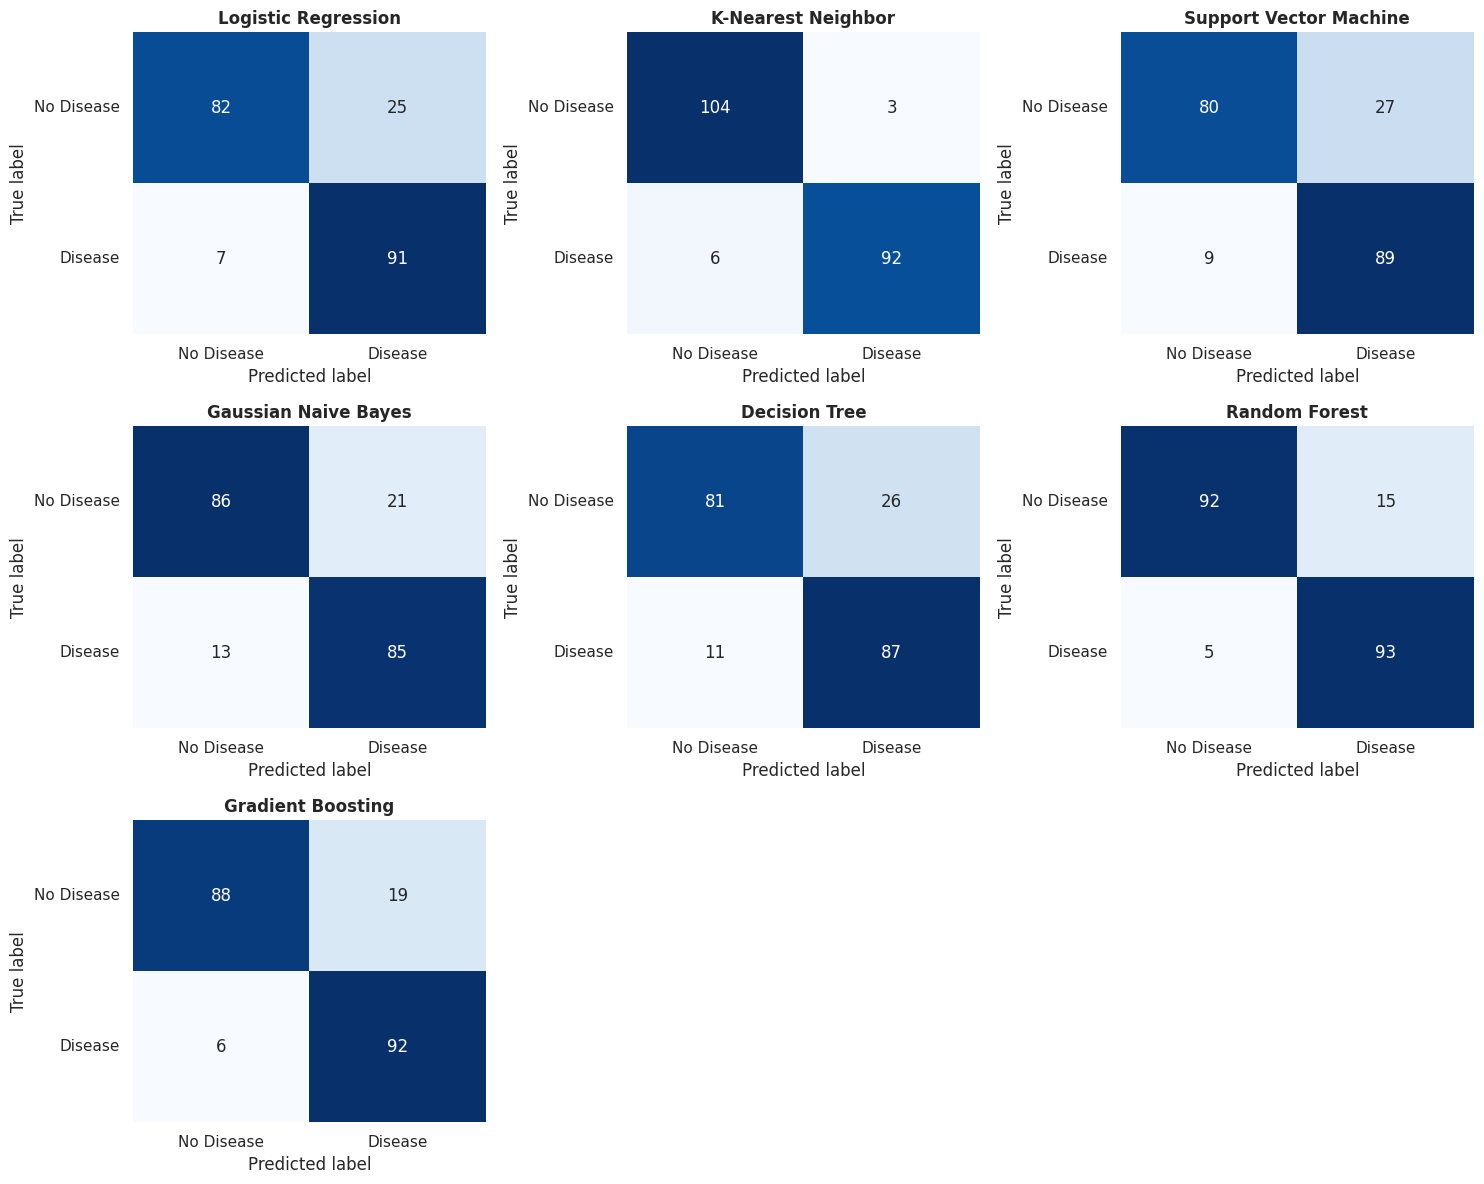

In [48]:
# I plot confusion matrices for all models to inspect the type of errors each model makes.
# Rows show the true class and columns show the predicted class.

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for ax, (model_name, predictions) in zip(axes, model_predictions.items()):
    cm = confusion_matrix(y_test, predictions)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(model_name, fontweight="bold")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticklabels(["No Disease", "Disease"])
    ax.set_yticklabels(["No Disease", "Disease"], rotation=0)

# Remove unused empty subplot spaces.
for j in range(len(model_predictions), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


**Chart analysis:** The most important part to watch is the number of false negatives, because these are patients who actually have heart disease but the model predicts as no disease. A model with slightly lower accuracy may still be more useful if it reduces false negatives.

From the confusion matrices, **Random Forest** has the lowest number of false negatives, with only **5 heart-disease cases incorrectly predicted as no disease**. This is important in a medical prediction task because missing a patient with heart disease can be more serious than giving a false warning.

**K-Nearest Neighbor** also performs very strongly. It has only **6 false negatives** and only **3 false positives**, which means it is not only good at detecting disease cases, but also avoids incorrectly labeling many healthy patients as diseased. This explains why KNN has the best overall performance in the metric table.

**Gradient Boosting** also has only **6 false negatives**, but it has more false positives than KNN. This means it detects most disease cases, but it is less precise when predicting disease.

Models such as **Gaussian Naive Bayes**, **Decision Tree**, and **Support Vector Machine** have more false negatives, so they miss more actual heart-disease cases compared with KNN, Random Forest, and Gradient Boosting.

Overall, the confusion matrices support the metric results: **KNN is the best balanced model**, while **Random Forest is especially strong if the goal is to minimize missed disease cases**.

### 10.3 Detailed classification reports

The classification report shows precision, recall, and F1-score separately for both classes. This helps check whether the model performs well for both `0 = no heart disease` and `1 = heart disease`.


In [49]:
# I print a detailed classification report for each model.
# This makes it easier to see whether one class is being predicted better than the other.

for model_name, predictions in model_predictions.items():
    print("=" * 70)
    print(model_name)
    print("=" * 70)
    print(classification_report(
        y_test,
        predictions,
        target_names=["No Heart Disease", "Heart Disease"],
        zero_division=0
    ))


Logistic Regression
                  precision    recall  f1-score   support

No Heart Disease       0.92      0.77      0.84       107
   Heart Disease       0.78      0.93      0.85        98

        accuracy                           0.84       205
       macro avg       0.85      0.85      0.84       205
    weighted avg       0.86      0.84      0.84       205

K-Nearest Neighbor
                  precision    recall  f1-score   support

No Heart Disease       0.95      0.97      0.96       107
   Heart Disease       0.97      0.94      0.95        98

        accuracy                           0.96       205
       macro avg       0.96      0.96      0.96       205
    weighted avg       0.96      0.96      0.96       205

Support Vector Machine
                  precision    recall  f1-score   support

No Heart Disease       0.90      0.75      0.82       107
   Heart Disease       0.77      0.91      0.83        98

        accuracy                           0.82       205
  

**Result interpretation:** If one class has much lower recall or F1-score, that means the model is not treating both classes equally well. Since this is a health-related dataset, I would not rely only on the highest accuracy; I would also check whether the model detects the heart-disease class reliably.

From the classification reports, **K-Nearest Neighbor** gives the strongest and most balanced result. Both classes have high precision, recall, and F1-score, and there is no large gap between the “No Heart Disease” and “Heart Disease” classes. This suggests that KNN is not only accurate overall, but also performs consistently for both groups.

**Random Forest** is also a strong model. It has a high recall of **0.95** for the heart-disease class, which means it detects most of the patients who actually have heart disease. However, its recall for the no-heart-disease class is lower at **0.86**, so it makes more false-positive predictions than KNN.

**Gradient Boosting** shows a similar pattern. It has high recall for heart disease, but lower recall for no heart disease. This means it is good at finding positive cases, but it may incorrectly label more healthy patients as having heart disease.

**Logistic Regression** and **Support Vector Machine** also detect the heart-disease class fairly well, with high recall values, but their precision for that class is lower. This means they catch many disease cases, but they also produce more false alarms.

Overall, **KNN is the best model in this comparison because it has the highest accuracy and the most balanced precision, recall, and F1-score across both classes**. At the same time, **Random Forest is still useful to consider because it has very strong recall for heart-disease cases**, which is important in a medical prediction problem.

### 10.4 Cross-validation

The earlier results are based on one train/test split. Cross-validation gives a stronger estimate because the model is trained and tested on several different folds of the data. I use stratified 5-fold cross-validation so that each fold keeps a similar class distribution.


In [50]:
# I use cross-validation to check whether the model performance is stable across different splits.
# The scaler is placed inside the pipeline, so it is fitted only on the training part of each fold.
# This avoids data leakage during cross-validation.

x_cv = x_unscaled.copy()

# Some categorical columns were stored as object type earlier, so I convert them back to numeric values for modeling.
for col in x_cv.select_dtypes(include=["object", "category"]).columns:
    x_cv[col] = pd.to_numeric(x_cv[col], errors="coerce")

x_cv = x_cv.astype(float)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

cv_models = {
    "Logistic Regression": Pipeline([
        ("scaler", MinMaxScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=1, solver="liblinear", penalty="l1"))
    ]),
    "K-Nearest Neighbor": Pipeline([
        ("scaler", MinMaxScaler()),
        ("model", KNeighborsClassifier(n_neighbors=3))
    ]),
    "Support Vector Machine": Pipeline([
        ("scaler", MinMaxScaler()),
        ("model", SVC(kernel="linear", max_iter=1000, C=10))
    ]),
    "Gaussian Naive Bayes": Pipeline([
        ("scaler", MinMaxScaler()),
        ("model", GaussianNB(var_smoothing=0.1))
    ]),
    "Decision Tree": Pipeline([
        ("scaler", MinMaxScaler()),
        ("model", DecisionTreeClassifier(
            max_depth=3,
            min_samples_leaf=5,
            criterion="entropy",
            min_samples_split=5,
            splitter="random",
            random_state=1
        ))
    ]),
    "Random Forest": Pipeline([
        ("scaler", MinMaxScaler()),
        ("model", RandomForestClassifier(
            n_estimators=1000,
            random_state=1,
            max_leaf_nodes=20,
            min_samples_split=15
        ))
    ]),
    "Gradient Boosting": Pipeline([
        ("scaler", MinMaxScaler()),
        ("model", GradientBoostingClassifier(
            random_state=1,
            n_estimators=100,
            max_leaf_nodes=3,
            loss="exponential",
            min_samples_leaf=20
        ))
    ])
}

cv_rows = []

for model_name, model in cv_models.items():
    scores = cross_validate(
        model,
        x_cv,
        y,
        cv=cv,
        scoring=["accuracy", "precision", "recall", "f1"],
        n_jobs=-1
    )

    cv_rows.append({
        "Model": model_name,
        "CV Accuracy Mean (%)": scores["test_accuracy"].mean() * 100,
        "CV Accuracy Std (%)": scores["test_accuracy"].std() * 100,
        "CV Precision Mean (%)": scores["test_precision"].mean() * 100,
        "CV Recall Mean (%)": scores["test_recall"].mean() * 100,
        "CV F1 Mean (%)": scores["test_f1"].mean() * 100
    })

cv_results_df = pd.DataFrame(cv_rows)
cv_results_df = cv_results_df.sort_values(by="CV F1 Mean (%)", ascending=False)

cv_results_df.style.format({
    "CV Accuracy Mean (%)": "{:.2f}",
    "CV Accuracy Std (%)": "{:.2f}",
    "CV Precision Mean (%)": "{:.2f}",
    "CV Recall Mean (%)": "{:.2f}",
    "CV F1 Mean (%)": "{:.2f}"
}).background_gradient(cmap="PuRd")


,Model,CV Accuracy Mean (%),CV Accuracy Std (%),CV Precision Mean (%),CV Recall Mean (%),CV F1 Mean (%)
1,K-Nearest Neighbor,94.83,2.17,95.30,94.67,94.95
5,Random Forest,89.85,3.26,88.30,92.58,90.36
6,Gradient Boosting,88.49,1.50,87.18,91.06,89.02
0,Logistic Regression,85.27,1.36,83.94,88.21,85.99
2,Support Vector Machine,84.59,1.59,81.73,90.10,85.68
3,Gaussian Naive Bayes,84.10,2.65,85.24,83.65,84.38
4,Decision Tree,83.61,3.19,83.24,85.55,84.30


**Result interpretation:** Cross-validation is more reliable than a single train/test split because it checks whether the model performs consistently across several partitions of the dataset. A strong final model should have both a high mean score and a reasonably low standard deviation.

The cross-validation results confirm that **K-Nearest Neighbor** is the strongest model overall. It has the highest mean accuracy at **94.83%**, the highest mean precision at **95.30%**, and the highest mean F1-score at **94.95%**. Its standard deviation is also reasonable at **2.17%**, which means its performance stays fairly consistent across different folds.

**Random Forest** is the second-best model based on cross-validation F1-score. It has a lower mean accuracy than KNN, but it has the highest mean recall at **92.58%**. This means Random Forest is especially good at detecting heart-disease cases, although its standard deviation is slightly higher at **3.26%**, so its performance changes more between folds.

**Gradient Boosting** also performs well, with a mean F1-score of **89.02%** and the lowest standard deviation among the stronger models at **1.50%**. This suggests that Gradient Boosting is stable, but its overall performance is still lower than KNN and Random Forest.

The simpler models, such as **Logistic Regression**, **Support Vector Machine**, **Gaussian Naive Bayes**, and **Decision Tree**, have lower cross-validation scores. They are still useful as baselines, but they do not perform as strongly as KNN in this project.

Overall, the cross-validation results support the earlier test-set results: **K-Nearest Neighbor is the best final model because it has the strongest average performance and remains fairly stable across folds**. However, **Random Forest is also important to consider if the main goal is maximizing recall for heart-disease detection**.

### 10.5 Final decision using stronger evidence

Now I compare the best model from the single test split with the best model from cross-validation. This makes the final conclusion more careful and evidence-based.


In [51]:
# I summarize the strongest models based on the stronger evaluation tables.

best_test_model = test_metrics_df.iloc[0]
best_cv_model = cv_results_df.iloc[0]

print("Best model on the single test split by F1-score:")
print(f"- {best_test_model['Model']} | F1-score = {best_test_model['F1-score (%)']:.2f}% | Accuracy = {best_test_model['Accuracy (%)']:.2f}%")

print("\nBest model under 5-fold cross-validation by mean F1-score:")
print(f"- {best_cv_model['Model']} | CV F1 = {best_cv_model['CV F1 Mean (%)']:.2f}% | CV Accuracy = {best_cv_model['CV Accuracy Mean (%)']:.2f}% ± {best_cv_model['CV Accuracy Std (%)']:.2f}%")


Best model on the single test split by F1-score:
- K-Nearest Neighbor | F1-score = 95.34% | Accuracy = 95.61%

Best model under 5-fold cross-validation by mean F1-score:
- K-Nearest Neighbor | CV F1 = 94.95% | CV Accuracy = 94.83% ± 2.17%


### Final conclusion after improvement

After adding duplicate checking, confusion matrices, precision/recall/F1-score, and cross-validation, the final model choice is no longer based only on one accuracy value. If the same model remains strongest in both the single test split and cross-validation, then I can make a stronger claim that it is the best model in this experiment. If the ranking changes, then the safer conclusion is that the original train/test split was not enough and the cross-validation result should be trusted more.

Overall, this improved evaluation makes the project more complete because it checks both model performance and model reliability.

In this project, **K-Nearest Neighbor is the strongest final model**. It gives the best result on the single test split, with an F1-score of **95.34%** and an accuracy of **95.61%**. It also remains the best model under 5-fold cross-validation, with a mean F1-score of **94.95%** and a mean accuracy of **94.83% ± 2.17%**. Since KNN performs best in both evaluations, the conclusion is more reliable than choosing a model from only one train/test split.

The confusion matrices and classification reports also support this choice. KNN has a strong balance between precision and recall for both classes, meaning it does not only perform well overall but also handles both “No Heart Disease” and “Heart Disease” cases consistently. This is especially important for a health-related dataset, where missing disease cases can be a serious problem.

At the same time, **Random Forest is still worth mentioning** because it has very strong recall for the heart-disease class. If the main goal were to reduce missed heart-disease cases as much as possible, Random Forest could also be considered. However, based on the full evaluation, **KNN is the best overall model for this experiment**.
